In [1]:
# If running on a fresh environment, you may need to install:
# pip install numpy scipy scikit-learn matplotlib mdtraj mdanalysis tqdm seaborn


# Notes:
# - Notebook uses mdtraj if present, else MDAnalysis. mdtraj keeps units in nm.
# - If MD trajectory dt is not discoverable, code assumes dt=1.0 time unit for MD-derived calculations

In [2]:
# Cell 2 — Imports & setup
import os
import math
import logging
from functools import partial
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from scipy.spatial.distance import cdist
from scipy.linalg import expm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import hdbscan


# Try mdtraj then MDAnalysis
try:
    import mdtraj as md
    backend = 'mdtraj'
except Exception:
    md = None
    try:
        import MDAnalysis as mda
        backend = 'mda'
    except Exception:
        mda = None
        backend = None

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('ctmc_nb')


# plotting defaults
sns.set(style='whitegrid')
np.set_printoptions(precision=4, suppress=True)


rng = np.random.default_rng()


def sample_categorical(probs, rng_local=None):
    if rng_local is None:
        rng_local = rng
    probs = np.asarray(probs, dtype=float)
    tot = probs.sum()
    if tot <= 0:
        return int(rng_local.integers(0, probs.shape[0]))
    return int(rng_local.choice(len(probs), p=(probs / tot)))

print('backend =', backend)

backend = mdtraj


In [3]:
# Cell 3 — PARAMETERS (edit these paths/options)
PARAMS = {
    'mc_traj_path': 'ala_dipeptide_mc.dcd',
    'mc_topology': 'alanine_amber_input.pdb',
    'md_traj_path': 'alanine-dipeptide-long-event-traj.pdb',
    # 'md_traj_path': 'alanine-dipeptide/unwrapped_0.dcd',
    'md_topology': 'alanine-dipeptide-load.pdb',

    'use_dihedrals': True,
    'n_pca': 2,
    'cluster_algorithm': 'hdbscan',  # 'kmeans' or 'hdbscan'
    'n_clusters': 4,
    'k_neighbors': 3,
    'adjacency_mode': 'combined',  # 'delaunay', 'transitions', 'combined', 'union'

    'neighbor_median_weight': 0.1,
    'initial_k0': 1.0,

    # scale_method: 'none', 'mfpt', 'md'
    'scale_method': 'md',
    'md_scale_by': 'slowest_mode',  # 'max_exit' or 'frobenius or slowest_exit or slowest_mode'

    'mfpt_macro_choice': 'largest_to_farthest',

    'T_final': 1000.0,
    'initial_cluster': None,

    'outputs_dir': 'alanine_dipeptide_ctmc_outputs',
    'sim_runs': 50,
    'max_models': 5000,
    'sim_random_start': False,
    'sim_view_index': 0,
    # directory containing multiple MD trajectories (optional)
    'md_dir': 'alanine-dipeptide-old',  # e.g. 'events_inputs'
}

os.makedirs(PARAMS['outputs_dir'], exist_ok=True)

for key in ['mc_traj_path', 'mc_topology', 'md_traj_path', 'md_topology']:
    if not os.path.exists(PARAMS[key]):
        logger.warning(f"File {PARAMS[key]} not found. Please set PARAMS['{key}'] to your path.")

PARAMS['n_clusters'] = int(PARAMS['n_clusters'])

In [4]:
# Cell 4 — Helper functions: IO & featurization
def load_trajectory(traj_path, top_path=None):
    if backend == 'mdtraj':
        return md.load(traj_path, top=top_path)
    elif backend == 'mda':
        return mda.Universe(top_path, traj_path)
    else:
        raise RuntimeError('No trajectory backend available. Install mdtraj or MDAnalysis.')


def infer_dt(traj_obj):
    if backend == 'mdtraj' and isinstance(traj_obj, md.Trajectory):
        return float(getattr(traj_obj, 'timestep', None)) if getattr(traj_obj, 'timestep', None) is not None else None
    elif backend == 'mda' and isinstance(traj_obj, mda.Universe):
        try:
            return float(traj_obj.trajectory.dt)
        except Exception:
            return None
    return None


def compute_features(traj_obj, use_dihedrals=True):
    def find_dihedral_quads(topology):
        neigh = {a.index: set() for a in topology.atoms}
        for bond in topology.bonds:
            i = bond[0].index; j = bond[1].index
            neigh[i].add(j); neigh[j].add(i)
        quads = []
        for bond in topology.bonds:
            b = bond[0].index; c = bond[1].index
            for a in neigh[b]:
                if a == c: continue
                for d in neigh[c]:
                    if d == b: continue
                    quads.append([a,b,c,d])
        uniq = []
        seen = set()
        for q in quads:
            t = tuple(q)
            if t not in seen:
                seen.add(t); uniq.append(t)
        return np.array(uniq, dtype=int)

    if backend == 'mdtraj' and isinstance(traj_obj, md.Trajectory) and use_dihedrals:
        try:
            phi_idx, phi_vals = md.compute_phi(traj_obj)
            psi_idx, psi_vals = md.compute_psi(traj_obj)
            thetas = np.hstack([phi_vals, psi_vals])
            if thetas.size > 0:
                feats = np.concatenate([np.sin(thetas), np.cos(thetas)], axis=1)
                return feats
        except Exception:
            logger.info('phi/psi extraction failed; attempting generic dihedrals')
        try:
            dihedral_indices = find_dihedral_quads(traj_obj.topology)
            if dihedral_indices.shape[0] > 0:
                dihedrals = md.compute_dihedrals(traj_obj, dihedral_indices)
                feats = np.concatenate([np.sin(dihedrals), np.cos(dihedrals)], axis=1)
                return feats
        except Exception as e:
            logger.info(f'generic dihedral extraction failed: {e}')

    # fallback: pairwise distances + PCA
    if backend == 'mdtraj' and isinstance(traj_obj, md.Trajectory):
        heavy_atoms = [a.index for a in traj_obj.topology.atoms if a.element.symbol != 'H']
        if len(heavy_atoms) > 30:
            heavy_atoms = heavy_atoms[:30]
        coords = traj_obj.xyz[:, heavy_atoms, :]
        n = coords.shape[1]
        pairs = [(i,j) for i in range(n) for j in range(i+1, n)]
        D = np.empty((coords.shape[0], len(pairs)), dtype=float)
        for t in range(coords.shape[0]):
            c = coords[t]
            D[t] = [np.linalg.norm(c[i]-c[j]) for (i,j) in pairs]
        pca = PCA(n_components=min(50, D.shape[1]))
        Dred = pca.fit_transform(D)
        return Dred
    elif backend == 'mda' and isinstance(traj_obj, mda.Universe):
        ag = traj_obj.select_atoms('not name H*')
        if len(ag) > 30:
            ag = ag[:30]
        frames = []
        for ts in traj_obj.trajectory:
            frames.append(ag.positions.copy())
        coords = np.array(frames)
        n = coords.shape[1]
        pairs = [(i,j) for i in range(n) for j in range(i+1, n)]
        D = np.empty((coords.shape[0], len(pairs)), dtype=float)
        for t in range(coords.shape[0]):
            c = coords[t]
            D[t] = [np.linalg.norm(c[i]-c[j]) for (i,j) in pairs]
        pca = PCA(n_components=min(50, D.shape[1]))
        Dred = pca.fit_transform(D)
        return Dred
    else:
        raise RuntimeError('Unsupported trajectory object for featurization')

print('Helper functions loaded')

Helper functions loaded


In [5]:
# Cell 5 — Load MC frames and MD short traj (if available) and compute features
mc_traj = None
md_traj = None
feats_mc = None
feats_md = None
labels_md = None

try:
    mc_traj = load_trajectory(PARAMS['mc_traj_path'], PARAMS['mc_topology'])
    logger.info('Loaded MC trajectory')
except Exception as e:
    logger.warning(f'Could not load MC trajectory: {e}')

try:
    md_traj = load_trajectory(PARAMS['md_traj_path'], PARAMS['md_topology'])
    logger.info('Loaded MD trajectory')
except Exception as e:
    logger.warning(f'Could not load MD trajectory: {e}')

if mc_traj is not None:
    feats_mc = compute_features(mc_traj, use_dihedrals=PARAMS['use_dihedrals'])
    logger.info(f'Computed MC features shape: {feats_mc.shape}')
else:
    raise RuntimeError('No MC features computed. Cannot continue.')

if md_traj is not None:
    try:
        feats_md = compute_features(md_traj, use_dihedrals=PARAMS['use_dihedrals'])
        logger.info(f'Computed MD features shape: {feats_md.shape}')
    except Exception as e:
        logger.warning(f'Could not compute MD features: {e}')
        feats_md = None

# infer dt (if available)
dt_md = infer_dt(md_traj) if md_traj is not None else None
#################### debug
dt_md = 0.16 ## set to 0.16 ps for alanine dipeptide example
#################### debug
if dt_md is None:
    # fallback default for MD dt
    dt_md = 1.0
    logger.info('MD dt not inferred; using dt_md = 1.0')

logger.info(f'Inferred MD dt = {dt_md}')
print('Loaded and featurized')

INFO:ctmc_nb:Loaded MC trajectory
INFO:ctmc_nb:Loaded MD trajectory
INFO:ctmc_nb:Computed MC features shape: (100000, 4)
INFO:ctmc_nb:Computed MD features shape: (93751, 4)
INFO:ctmc_nb:Inferred MD dt = 0.16


Loaded and featurized


Number of noise frames (label -1) = 7820
HDBSCAN found 4 clusters
Cluster counts = [27598  4454 55235 12713]
Cluster populations (pi) = [0.276  0.0445 0.5524 0.1271]


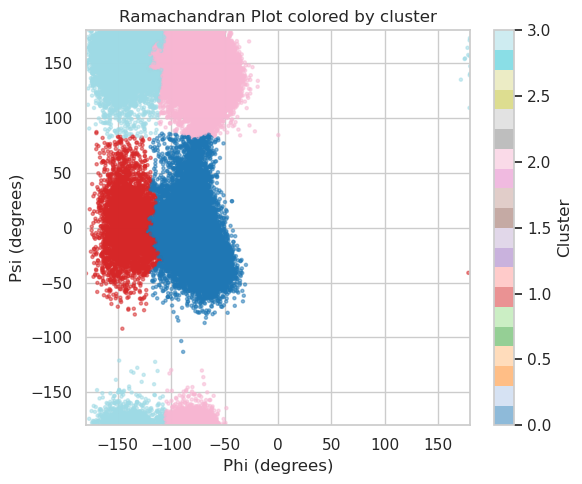

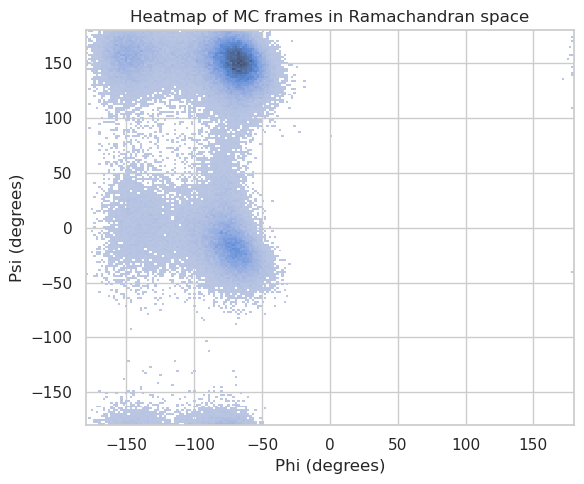

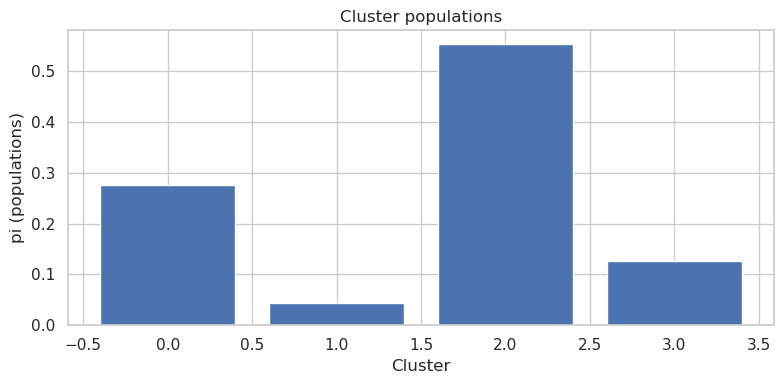

INFO:ctmc_nb:Clusters min/max counts = 4454/55235
INFO:ctmc_nb:Initial cluster set to 2


In [6]:
# Cell 6 — Clustering + visualization (PCA embedding, Ramachandran, populations)
if PARAMS['cluster_algorithm'] == 'kmeans':
    N = PARAMS['n_clusters']
    logger.info(f'Clustering into N={N} clusters')
    km = KMeans(n_clusters=N, random_state=42, n_init=20)
    labels = km.fit_predict(feats_mc)
    print(f'Cluster labels for MC frames - 0: {np.sum(labels==0)}, 1: {np.sum(labels==1)}, 2: {np.sum(labels==2)}')
    centroids = km.cluster_centers_
    counts = np.bincount(labels, minlength=N)
    print(f'Cluster counts = {counts}')
    pi = counts / counts.sum()
    print(f'Cluster populations (pi) = {pi}')
else:
###################### HDBSCAN clustering
    N = PARAMS['n_clusters']
    clusterer = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=50)
    labels = clusterer.fit_predict(feats_mc)
    # -1 labels are "noise" — assign to nearest cluster after
    n_found = len(set(labels)) - (1 if -1 in labels else 0)
    print(f'Number of noise frames (label -1) = {(labels == -1).sum()}')
    print(f'HDBSCAN found {n_found} clusters')

    # reassign noise points to nearest cluster centroid
    if (labels == -1).sum() > 0 and n_found > 0:
        noise_indices = np.where(labels == -1)[0]
        if n_found > 0:
            centroids = np.array([clusterer.weighted_cluster_centroid(i) for i in range(n_found)])
            d_noise_to_cent = cdist(feats_mc[noise_indices], centroids)
            nearest_clusters = np.argmin(d_noise_to_cent, axis=1)
            labels[noise_indices] = nearest_clusters

    # get centroids of found clusters
    # centroids = np.array([feats_mc[labels_hdb == i].mean(axis=0) for i in range(n_found)])
    centroids = np.array([clusterer.weighted_cluster_centroid(i) for i in range(n_found)])
    counts = np.bincount(labels, minlength=N)
    print(f'Cluster counts = {counts}')
    pi = counts / counts.sum()
    print(f'Cluster populations (pi) = {pi}')
###################### HDBSCAN clustering

# assign MD frames to clusters (if feats_md available)
labels_md = None
if feats_md is not None:
    d_md_to_cent = cdist(feats_md, centroids)
    labels_md = np.argmin(d_md_to_cent, axis=1)

# Ramachandran plot if possible
if backend == 'mdtraj' and isinstance(mc_traj, md.Trajectory) and PARAMS['use_dihedrals']:
    try:
        phi_idx, phi_vals = md.compute_phi(mc_traj)
        psi_idx, psi_vals = md.compute_psi(mc_traj)
        thetas = np.hstack([phi_vals, psi_vals])
        if thetas.size > 0:
            plt.figure(figsize=(6,5))
            scatter = plt.scatter(np.degrees(thetas[:,0]), np.degrees(thetas[:,1]), c=labels, s=5, cmap='tab20', alpha=0.5)
            plt.xlabel('Phi (degrees)'); plt.ylabel('Psi (degrees)')
            plt.title('Ramachandran Plot colored by cluster')
            plt.xlim([-180,180]); plt.ylim([-180,180])
            plt.colorbar(scatter, label='Cluster')
            plt.tight_layout(); plt.show()
    except Exception as e:
        logger.info(f'Could not plot Ramachandran with clusters: {e}')

# Heatmap of cluster assignments for MC frames in phi/psi space (if dihedrals available)
if backend == 'mdtraj' and isinstance(mc_traj, md.Trajectory) and PARAMS['use_dihedrals']:
    try:
        phi_idx, phi_vals = md.compute_phi(mc_traj)
        psi_idx, psi_vals = md.compute_psi(mc_traj)
        thetas = np.hstack([phi_vals, psi_vals])
        if thetas.size > 0:
            plt.figure(figsize=(6,5))
            sns.histplot(x=np.degrees(thetas[:,0]), y=np.degrees(thetas[:,1]), bins=200, alpha=1.0)
            plt.xlabel('Phi (degrees)'); plt.ylabel('Psi (degrees)')
            plt.title('Heatmap of MC frames in Ramachandran space')
            plt.xlim([-180,180]); plt.ylim([-180,180])
            plt.tight_layout(); plt.show()
    except Exception as e:
        logger.info(f'Could not plot Ramachandran heatmap with clusters: {e}')

# populations bar chart
order = np.argsort(pi)[::-1]
plt.figure(figsize=(8,4))
plt.bar(np.arange(N), pi[:])
plt.xlabel('Cluster'); plt.ylabel('pi (populations)')
plt.title('Cluster populations')
plt.tight_layout(); plt.show()

logger.info(f'Clusters min/max counts = {counts.min()}/{counts.max()}')

if PARAMS['initial_cluster'] is None:
    initial_cluster = int(np.argmax(pi))
else:
    initial_cluster = int(PARAMS['initial_cluster'])
logger.info(f'Initial cluster set to {initial_cluster}')

INFO:ctmc_nb:Adjacency mode: combined
INFO:ctmc_nb:All states have at least one neighbor in adjacency_mask



Adjacency edges (combined):
  0 <-> 1  (transitions: 1942)
  0 <-> 2  (transitions: 364)
  1 <-> 2  (transitions: 11)
  1 <-> 3  (transitions: 113)
  2 <-> 3  (transitions: 3580)


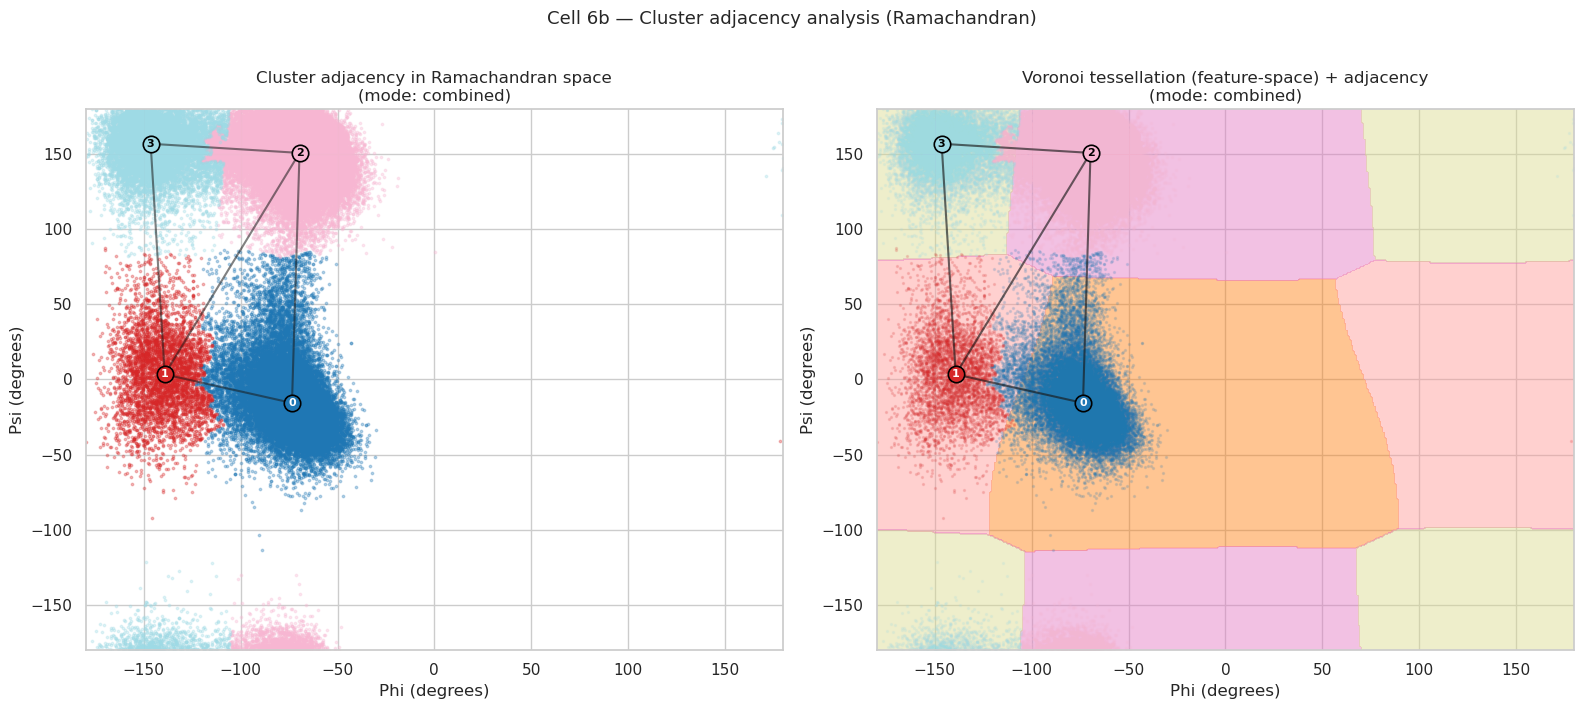

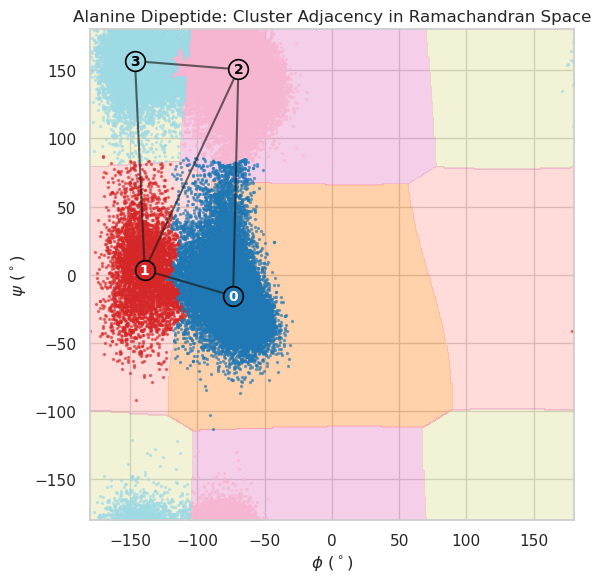

INFO:ctmc_nb:adjacency_mask built — 5 edges total


In [23]:
# %%
# Cell 6b — Cluster adjacency (Delaunay + transitions), Ramachandran-space visualization

from scipy.spatial import Delaunay

ADJACENCY_MODE = PARAMS.get('adjacency_mode', 'combined')

# ── 1. Delaunay adjacency in 2D phi/psi space (works for any N >= 4) ─────────
# compute centroid angles first (needed here and for plotting)
phi_idx, phi_vals = md.compute_phi(mc_traj)
psi_idx, psi_vals = md.compute_psi(mc_traj)
phi_all = np.degrees(phi_vals[:, 0])
psi_all = np.degrees(psi_vals[:, 0])

centroid_phi = np.degrees(np.arctan2(centroids[:, 0], centroids[:, 2]))
centroid_psi = np.degrees(np.arctan2(centroids[:, 1], centroids[:, 3]))

centroids_2d = np.column_stack([centroid_phi, centroid_psi])  # (N, 2)
tri = Delaunay(centroids_2d)

delaunay_adj = np.zeros((N, N), dtype=bool)
for simplex in tri.simplices:
    for i in range(len(simplex)):
        for j in range(i + 1, len(simplex)):
            a, b = simplex[i], simplex[j]
            delaunay_adj[a, b] = True
            delaunay_adj[b, a] = True

# ── 2. Transition adjacency (time-ordered MC frames) ─────────────────────────
transition_adj    = np.zeros((N, N), dtype=bool)
transition_counts = np.zeros((N, N), dtype=int)

for t in range(len(labels) - 1):
    a, b = int(labels[t]), int(labels[t + 1])
    if a != b:
        transition_adj[a, b] = True
        transition_adj[b, a] = True
        transition_counts[a, b] += 1
        transition_counts[b, a] += 1

# ── 3. Build adjacency_mask ───────────────────────────────────────────────────
if ADJACENCY_MODE == 'delaunay':
    adjacency_mask = delaunay_adj.copy()
elif ADJACENCY_MODE == 'transitions':
    adjacency_mask = transition_adj.copy()
elif ADJACENCY_MODE == 'union':
    adjacency_mask = delaunay_adj | transition_adj
else:  # 'combined'
    adjacency_mask = delaunay_adj & transition_adj

logger.info(f'Adjacency mode: {ADJACENCY_MODE}')

isolated = [i for i in range(N) if not adjacency_mask[i].any()]
if isolated:
    logger.warning(f'States with ZERO neighbors under adjacency_mask: {isolated}')
else:
    logger.info('All states have at least one neighbor in adjacency_mask')

print(f'\nAdjacency edges ({ADJACENCY_MODE}):')
for i in range(N):
    for j in range(i + 1, N):
        if adjacency_mask[i, j]:
            print(f'  {i} <-> {j}  (transitions: {transition_counts[i,j]})')

# ── 4. Recover phi/psi angles for all MC frames ───────────────────────────────
# features = [sin(phi), sin(psi), cos(phi), cos(psi)]  shape (n_frames, 4)
# centroids are in this same sin/cos space
phi_idx, phi_vals = md.compute_phi(mc_traj)
psi_idx, psi_vals = md.compute_psi(mc_traj)

phi_all = np.degrees(phi_vals[:, 0])   # one phi per frame for alanine dipeptide
psi_all = np.degrees(psi_vals[:, 0])   # one psi per frame

# centroid back-projection via atan2(sin, cos)
# feature layout: [sin_phi, sin_psi, cos_phi, cos_psi]
centroid_phi = np.degrees(np.arctan2(centroids[:, 0], centroids[:, 2]))  # atan2(sin_phi, cos_phi)
centroid_psi = np.degrees(np.arctan2(centroids[:, 1], centroids[:, 3]))  # atan2(sin_psi, cos_psi)

# ── 5. Voronoi tessellation on a phi/psi grid ─────────────────────────────────
# Dense grid in angle space → convert to sin/cos → assign to nearest centroid.
# This reproduces the exact same Voronoi boundaries used for cluster assignment.
_grid_res  = 400
_phi_grid  = np.linspace(-180, 180, _grid_res)
_psi_grid  = np.linspace(-180, 180, _grid_res)
_gp, _gs   = np.meshgrid(_phi_grid, _psi_grid)   # gp=phi axis, gs=psi axis
_gpf       = _gp.ravel()
_gsf       = _gs.ravel()

_grid_feats = np.column_stack([
    np.sin(np.radians(_gpf)),   # sin_phi
    np.sin(np.radians(_gsf)),   # sin_psi
    np.cos(np.radians(_gpf)),   # cos_phi
    np.cos(np.radians(_gsf)),   # cos_psi
])
_grid_dists  = cdist(_grid_feats, centroids)
_grid_labels = np.argmin(_grid_dists, axis=1).reshape(_grid_res, _grid_res)

# ── 6. Plots ──────────────────────────────────────────────────────────────────
cmap_pts = plt.get_cmap('tab20')
clr      = [cmap_pts(k / max(N - 1, 1)) for k in range(N)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Panel A: scatter + adjacency graph in Ramachandran space ─────────────────
ax = axes[0]
for k in range(N):
    mask_k = labels == k
    ax.scatter(phi_all[mask_k], psi_all[mask_k],
               s=3, alpha=0.3, color=clr[k], rasterized=True)

for i in range(N):
    for j in range(i + 1, N):
        if adjacency_mask[i, j]:
            ax.plot([centroid_phi[i], centroid_phi[j]],
                    [centroid_psi[i], centroid_psi[j]],
                    'k-', lw=1.5, alpha=0.55, zorder=3)

for k in range(N):
    ax.scatter(centroid_phi[k], centroid_psi[k],
               s=140, color=clr[k], edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(str(k), (centroid_phi[k], centroid_psi[k]),
                fontsize=8, ha='center', va='center',
                fontweight='bold', zorder=6,
                color='white' if np.mean(clr[k][:3]) < 0.6 else 'black')

ax.set_xlim([-180, 180]); ax.set_ylim([-180, 180])
ax.set_xlabel('Phi (degrees)'); ax.set_ylabel('Psi (degrees)')
ax.set_title(f'Cluster adjacency in Ramachandran space\n(mode: {ADJACENCY_MODE})')

# ── Panel B: Voronoi tessellation + adjacency ─────────────────────────────────
ax = axes[1]
ax.contourf(_gp, _gs, _grid_labels,
            levels=np.arange(-0.5, N + 0.5, 1),
            cmap='tab20', alpha=0.45)

for k in range(N):
    mask_k = labels == k
    ax.scatter(phi_all[mask_k], psi_all[mask_k],
               s=2, alpha=0.15, color=clr[k], rasterized=True)

for i in range(N):
    for j in range(i + 1, N):
        if adjacency_mask[i, j]:
            ax.plot([centroid_phi[i], centroid_phi[j]],
                    [centroid_psi[i], centroid_psi[j]],
                    'k-', lw=1.5, alpha=0.65, zorder=3)

for k in range(N):
    ax.scatter(centroid_phi[k], centroid_psi[k],
               s=140, color=clr[k], edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(str(k), (centroid_phi[k], centroid_psi[k]),
                fontsize=8, ha='center', va='center',
                fontweight='bold', zorder=6,
                color='white' if np.mean(clr[k][:3]) < 0.6 else 'black')

ax.set_xlim([-180, 180]); ax.set_ylim([-180, 180])
ax.set_xlabel('Phi (degrees)'); ax.set_ylabel('Psi (degrees)')
ax.set_title(f'Voronoi tessellation (feature-space) + adjacency\n(mode: {ADJACENCY_MODE})')

plt.suptitle('Cell 6b — Cluster adjacency analysis (Ramachandran)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# paper-ready version with only the Voronoi panel, well labeled and cropped
fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(_gp, _gs, _grid_labels,
            levels=np.arange(-0.5, N + 0.5, 1),
            cmap='tab20', alpha=0.35)
for k in range(N):
    mask_k = labels == k
    ax.scatter(phi_all[mask_k], psi_all[mask_k],
               s=2, alpha=0.55, color=clr[k], rasterized=True)
for i in range(N):
    for j in range(i + 1, N):
        if adjacency_mask[i, j]:
            ax.plot([centroid_phi[i], centroid_phi[j]],
                    [centroid_psi[i], centroid_psi[j]],
                    'k-', lw=1.5, alpha=0.65, zorder=3)
for k in range(N):
    ax.scatter(centroid_phi[k], centroid_psi[k],
               s=200, color=clr[k], edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(str(k), (centroid_phi[k], centroid_psi[k]),
                fontsize=10, ha='center', va='center',
                fontweight='bold', zorder=6,
                color='white' if np.mean(clr[k][:3]) < 0.6 else 'black')
ax.set_xlim([-180, 180]); ax.set_ylim([-180, 180])
ax.set_xlabel('$\\phi$ ($^\circ$)'); ax.set_ylabel('$\\psi$ ($^\circ$)')
ax.set_title(f'Alanine Dipeptide: Cluster Adjacency in Ramachandran Space', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PARAMS['outputs_dir'], f'cell6b_ramachandran_adjacency_{ADJACENCY_MODE}.png'), dpi=300)
plt.show()

logger.info(f'adjacency_mask built — {adjacency_mask.sum()//2} edges total')

INFO:ctmc_nb:Cell 7: using adjacency_mask from Cell 6b (5 edges)


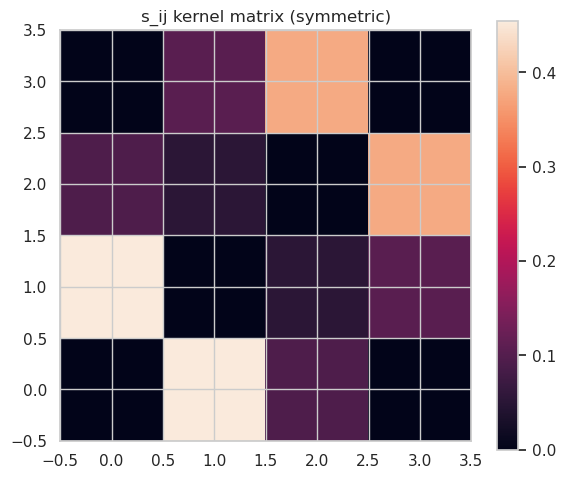

In [8]:
# Cell 7 — Build k-NN graph, s_ij and visualize
k = int(PARAMS['k_neighbors'])
nbrs = NearestNeighbors(n_neighbors=min(k+1, N), algorithm='auto').fit(centroids)
distances, indices = nbrs.kneighbors(centroids)
kNN_dists = distances[:,1:] if distances.shape[1]>1 else np.zeros((N,0))
kNN_idx = indices[:,1:] if indices.shape[1]>1 else np.zeros((N,0), dtype=int)

# build symmetric adjacency from k-NN (undirected graph)
# adj = np.zeros((N,N), dtype=bool)
# for i in range(N):
#     for j in np.atleast_1d(kNN_idx[i]):
#         adj[i,int(j)] = True
# adj = np.logical_or(adj, adj.T)

# for simplicity, use the same adjacency_mask from Cell 6b (e.g. Delaunay, transitions, or combined) instead of strict k-NN graph
adj = adjacency_mask.copy()
logger.info(f'Cell 7: using adjacency_mask from Cell 6b ({adj.sum()//2} edges)')

# choose lambda via median kNN distance
if kNN_dists.size == 0:
    d0 = 0.0
else:
    d0 = np.median(kNN_dists)
w0 = float(PARAMS['neighbor_median_weight'])
if d0 <= 0:
    logger.warning('Median nearest-neighbor distance is zero; setting lambda=1.0')
    lam = 1.0
else:
    lam = -np.log(w0) / (d0**2)
k0 = float(PARAMS['initial_k0'])

s = np.zeros((N,N), dtype=float)
for i in range(N):
    for j in np.where(adj[i])[0]:
        s[i,j] = k0 * math.exp(-lam * (np.linalg.norm(centroids[i]-centroids[j])**2))
s = 0.5 * (s + s.T)

plt.figure(figsize=(6,5))
plt.imshow(s, origin='lower')
plt.title('s_ij kernel matrix (symmetric)')
plt.colorbar(); plt.tight_layout(); plt.show()

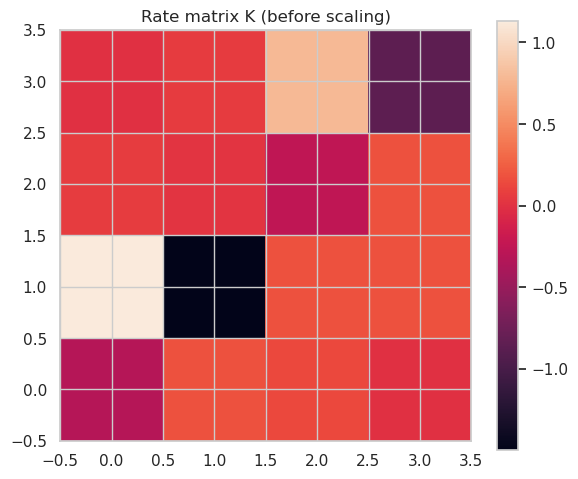

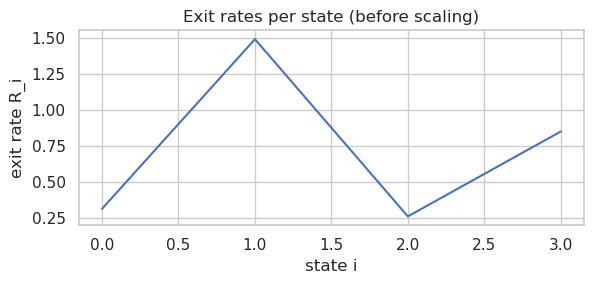

INFO:ctmc_nb:State 0: exit rate R_i = 0.3154
INFO:ctmc_nb:State 1: exit rate R_i = 1.4934
INFO:ctmc_nb:State 2: exit rate R_i = 0.2629
INFO:ctmc_nb:State 3: exit rate R_i = 0.8527


In [9]:
# Cell 8 — Construct K with detailed balance and inspect
K = np.zeros((N,N), dtype=float)
for i in range(N):
    for j in range(N):
        if i!=j and s[i,j] > 0:
            K[i,j] = s[i,j] * math.sqrt((pi[j]+1e-16)/(pi[i]+1e-16))
for i in range(N):
    K[i,i] = -K[i].sum()

plt.figure(figsize=(6,5))
plt.imshow(K, origin='lower')
plt.title('Rate matrix K (before scaling)')
plt.colorbar(); plt.tight_layout(); plt.show()

# exit rates
R = -np.diag(K)
plt.figure(figsize=(6,3))
plt.plot(R)
plt.xlabel('state i'); plt.ylabel('exit rate R_i')
plt.title('Exit rates per state (before scaling)')
plt.tight_layout(); plt.show()

for i in range(N):
    logger.info(f'State {i}: exit rate R_i = {R[i]:.4f}')

INFO:ctmc_nb:MFPT calibration: A=2 (largest-pop), B=1 (farthest)
INFO:ctmc_nb:Model MFPT A->B (before scaling) = 21.3741232648868
INFO:ctmc_nb:Empirical MFPT A->B from MD = 259.347786259542 (dt=0.16)


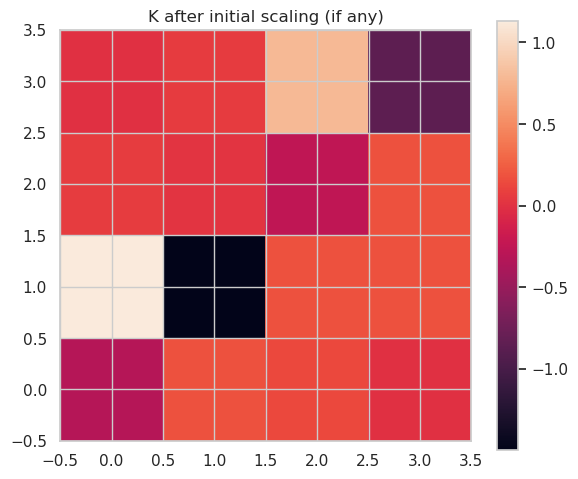

In [10]:
# Cell 9 — MFPT computation and estimation from MD

def mfpt_to_target_from_generator(Kmat, target_idx):
    Nn = Kmat.shape[0]
    transient = [i for i in range(Nn) if i != target_idx]
    K_RR = Kmat[np.ix_(transient, transient)]
    b = np.ones(len(transient))
    try:
        t_sol = np.linalg.solve(-K_RR, b)
    except np.linalg.LinAlgError:
        t_sol = np.linalg.solve(-K_RR - 1e-12*np.eye(K_RR.shape[0]), b)
    t_all = np.zeros(Nn)
    for ii, si in enumerate(transient):
        t_all[si] = t_sol[ii]
    t_all[target_idx] = 0.0
    return t_all

# choose A,B for MFPT
if isinstance(PARAMS['mfpt_macro_choice'], tuple):
    A_idx, B_idx = PARAMS['mfpt_macro_choice']
else:
    A_idx = int(np.argmax(pi))
    dists_from_A = np.linalg.norm(centroids - centroids[A_idx], axis=1)
    B_idx = int(np.argmax(dists_from_A))

logger.info(f'MFPT calibration: A={A_idx} (largest-pop), B={B_idx} (farthest)')

# model MFPT
t_model_to_B = mfpt_to_target_from_generator(K, B_idx)
mfpt_model_A_to_B = t_model_to_B[A_idx]
logger.info(f'Model MFPT A->B (before scaling) = {mfpt_model_A_to_B}')

# empirical MFPT from MD

def compute_empirical_mfpt_from_md(labels_md, A_idx, B_idx, dt=None):
    if labels_md is None:
        return None
    n = len(labels_md)
    hits = []
    i = 0
    while i < n:
        if labels_md[i] == A_idx:
            j = i+1
            while j < n:
                if labels_md[j] == B_idx:
                    delta_frames = j - i
                    time = delta_frames * (dt if dt is not None else 1.0)
                    hits.append(time)
                    break
                j += 1
            while i < n and labels_md[i] == A_idx:
                i += 1
        else:
            i += 1
    if len(hits) == 0:
        logger.warning('No A->B transitions observed in MD for MFPT estimation')
        return None
    return float(np.mean(hits)), np.array(hits)

mfpt_md_res = compute_empirical_mfpt_from_md(labels_md, A_idx, B_idx, dt=dt_md)
if mfpt_md_res is None:
    logger.warning('Could not compute empirical MFPT from MD; calibration option may be skipped.')
    mfpt_md_mean = None
else:
    mfpt_md_mean, hit_times = mfpt_md_res
    logger.info(f'Empirical MFPT A->B from MD = {mfpt_md_mean} (dt={dt_md})')

# scaling options
K_scaled = K.copy()
if PARAMS['scale_method'] == 'mfpt' and mfpt_md_mean is not None and mfpt_model_A_to_B > 0:
    scale_c = mfpt_model_A_to_B / mfpt_md_mean
    logger.info(f'Scaling factor c = {scale_c} (will set K := K * c)')
    K_scaled = K * scale_c
elif PARAMS['scale_method'] == 'md':
    # we will compute K_md below and then apply MD-based scaling
    pass
else:
    logger.info('Skipping scaling; using K as-is')

plt.figure(figsize=(6,5))
plt.imshow(K_scaled, origin='lower')
plt.title('K after initial scaling (if any)')
plt.colorbar(); plt.tight_layout(); plt.show()

INFO:ctmc_nb:Estimated K_md from MD labels


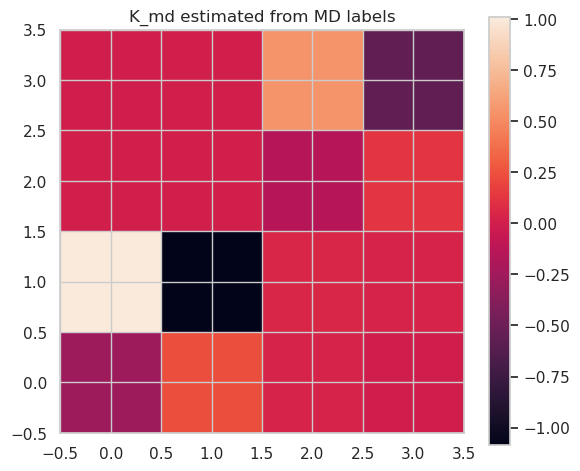

INFO:ctmc_nb:Slow-mode scaling: c=0.212, tau_model=4.244, tau_md=20.02


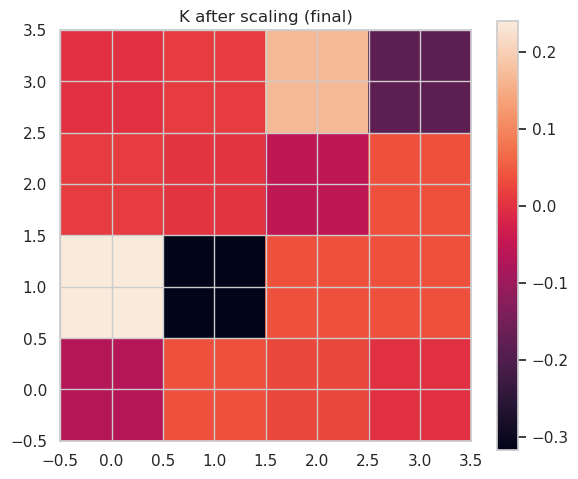

INFO:ctmc_nb:Model MFPT A->B (after scaling) = 100.82145896616227



MFPT comparison (A->B):
  MD empirical MFPT  : 259.35
  Model (before)     : 21.374
  Model (after scale): 100.82


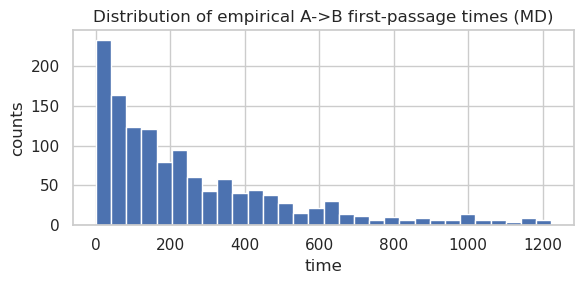

In [11]:
# Cell 10 — Estimate MD-derived generator K_md (moved earlier so it can be used for scaling)

def estimate_K_from_MD_labels(labels_md, dt_md, N):
    if labels_md is None:
        return None
    labels_md = np.asarray(labels_md, dtype=int)
    n = len(labels_md)
    changes = np.where(labels_md[1:] != labels_md[:-1])[0] + 1
    prev_states = labels_md[changes - 1]
    next_states = labels_md[changes]
    counts_md = np.zeros((N,N), dtype=float)
    for a,b in zip(prev_states, next_states):
        counts_md[int(a), int(b)] += 1
    change_frames = np.concatenate((changes, [n]))
    start_frames = np.concatenate(([0], changes))
    durations_frames = change_frames - start_frames
    states_during = labels_md[start_frames]
    time_in_state = np.zeros(N, dtype=float)
    for s, df in zip(states_during, durations_frames):
        time_in_state[int(s)] += df * (dt_md if dt_md is not None else 1.0)
    K_md = np.zeros((N,N), dtype=float)
    for i in range(N):
        if time_in_state[i] > 0:
            K_md[i, :] = counts_md[i, :] / time_in_state[i]
    for i in range(N):
        off_sum = np.sum(K_md[i, :]) - K_md[i, i]
        K_md[i, i] = -off_sum
    return K_md, time_in_state

K_md = None
md_time_in_state = None
if labels_md is not None:
    K_md_res = estimate_K_from_MD_labels(labels_md, dt_md, N)
    if K_md_res is not None:
        K_md, md_time_in_state = K_md_res
        logger.info('Estimated K_md from MD labels')

# inspect K_md
if K_md is not None:
    plt.figure(figsize=(6,5))
    plt.imshow(K_md, origin='lower')
    plt.title('K_md estimated from MD labels')
    plt.colorbar(); plt.tight_layout(); plt.show()

# If scale_method == 'md' and we have K_md, scale model accordingly
if PARAMS['scale_method'] == 'md' and K_md is not None:
    md_scale_by = PARAMS.get('md_scale_by', 'max_exit')
    if md_scale_by == 'max_exit':
        R_md = -np.diag(K_md)
        R_model = -np.diag(K)
        if np.max(R_md) > 0 and np.max(R_model) > 0:
            scale_md = np.max(R_model) / np.max(R_md)
            # user requested: "scale matrix based on MD matrix" — choose to scale K_model so that its max exit equals MD's
            # Here we set K_scaled = K * (max_md / max_model) to bring model to MD scale
            scale_md = np.max(R_md) / np.max(R_model)
            K_scaled = K * scale_md
            logger.info(f'scaling K by max_exit: factor {scale_md:.5g}')
    elif md_scale_by == 'frobenius':
        mask_off = ~np.eye(N, dtype=bool)
        fro_model = np.linalg.norm(K[mask_off])
        fro_md = np.linalg.norm(K_md[mask_off]) if K_md is not None else 0.0
        if fro_md > 0 and fro_model > 0:
            scale_md = fro_md / fro_model
            K_scaled = K * scale_md
            logger.info(f'scaling K by frobenius off-diag: factor {scale_md:.5g}')
    elif md_scale_by == 'slowest_exit':
        R_md = -np.diag(K_md)
        R_model = -np.diag(K)
        slow_md = np.min(R_md[R_md > 0]) if np.any(R_md > 0) else 0.0
        slow_model = np.min(R_model[R_model > 0]) if np.any(R_model > 0) else 0.0
        if slow_md > 0 and slow_model > 0:
            scale_md = slow_md / slow_model
            K_scaled = K * scale_md
            logger.info(f'scaling K by slowest_exit: factor {scale_md:.5g}')
    elif md_scale_by == 'slowest_mode':
        def get_slowest_eigval(Kmat, tol=1e-10):
            eigs = np.sort(np.real(np.linalg.eigvals(Kmat)))[::-1]
            nontrivial = eigs[eigs < -tol]
            return nontrivial[0] if len(nontrivial) > 0 else None
        
        lam_model = get_slowest_eigval(K)
        lam_md    = get_slowest_eigval(K_md)
        
        if lam_model is not None and lam_md is not None:
            c_slow = lam_md / lam_model
            K_scaled = K * c_slow
            logger.info(f'Slow-mode scaling: c={c_slow:.4g}, '
                        f'tau_model={-1/lam_model:.4g}, tau_md={-1/lam_md:.4g}')

# inspect scaled K
plt.figure(figsize=(6,5))
plt.imshow(K_scaled, origin='lower')
plt.title('K after scaling (final)')
plt.colorbar(); plt.tight_layout(); plt.show()

# confirm MFPT after scaling
t_model_to_B_scaled = mfpt_to_target_from_generator(K_scaled, B_idx)
mfpt_model_A_to_B_scaled = t_model_to_B_scaled[A_idx]
logger.info(f'Model MFPT A->B (after scaling) = {mfpt_model_A_to_B_scaled}')

if mfpt_md_mean is not None:
    print('\nMFPT comparison (A->B):')
    print(f'  MD empirical MFPT  : {mfpt_md_mean:.5g}')
    print(f'  Model (before)     : {mfpt_model_A_to_B:.5g}')
    print(f'  Model (after scale): {mfpt_model_A_to_B_scaled:.5g}')

if mfpt_md_mean is not None:
    plt.figure(figsize=(6,3))
    plt.hist(hit_times, bins=30)
    plt.title('Distribution of empirical A->B first-passage times (MD)')
    plt.xlabel('time'); plt.ylabel('counts'); plt.tight_layout(); plt.show()

Generated 92 events up to time 1.01e+03


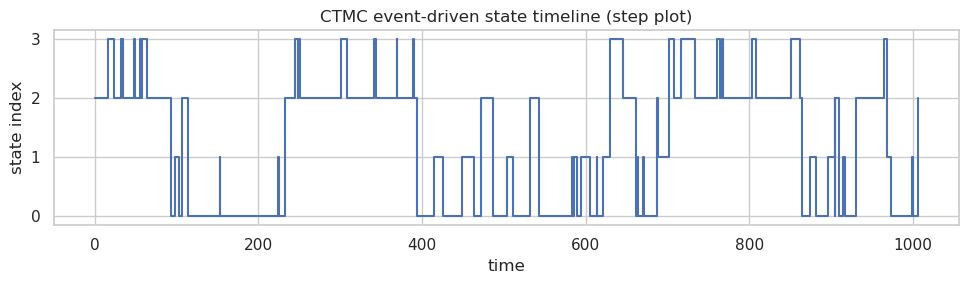

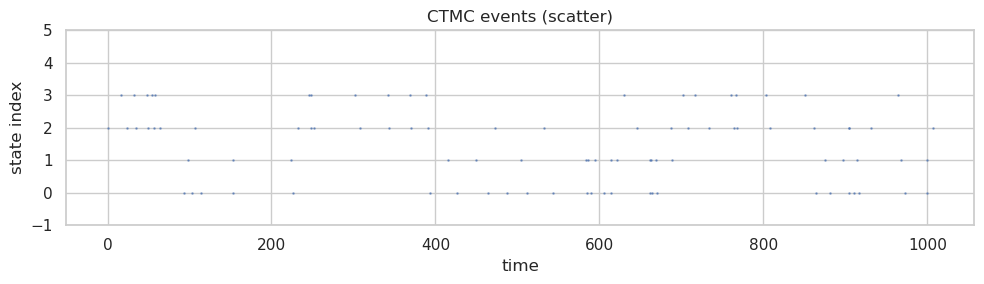

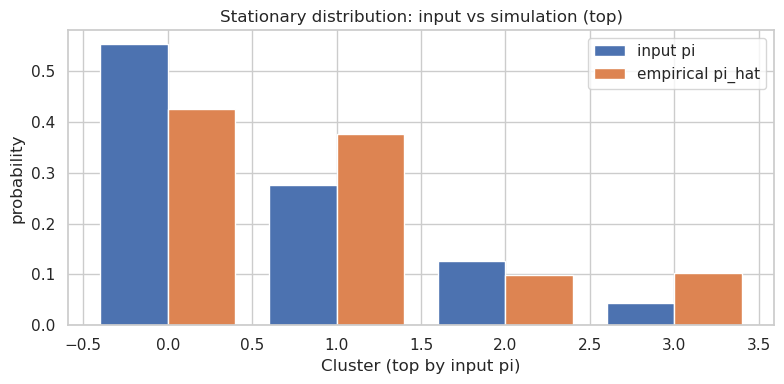

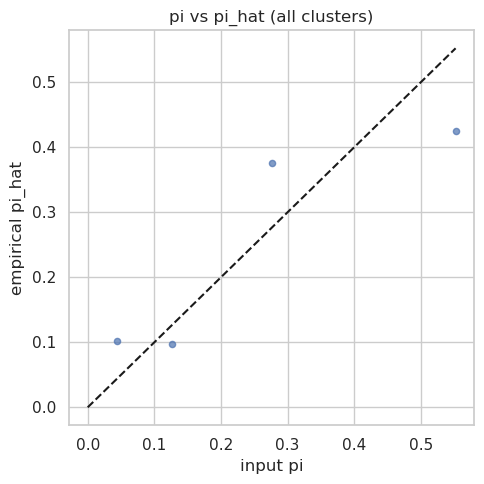

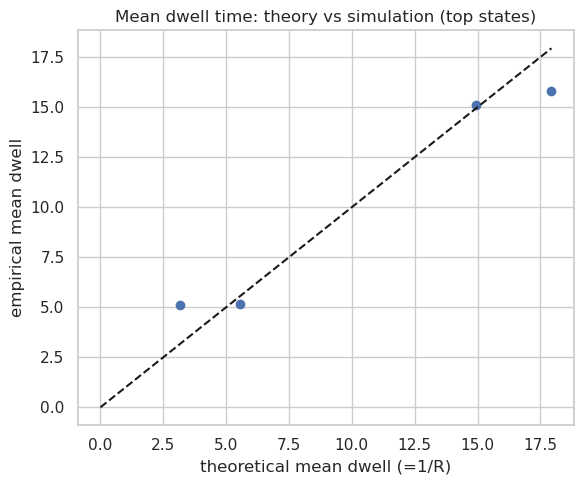

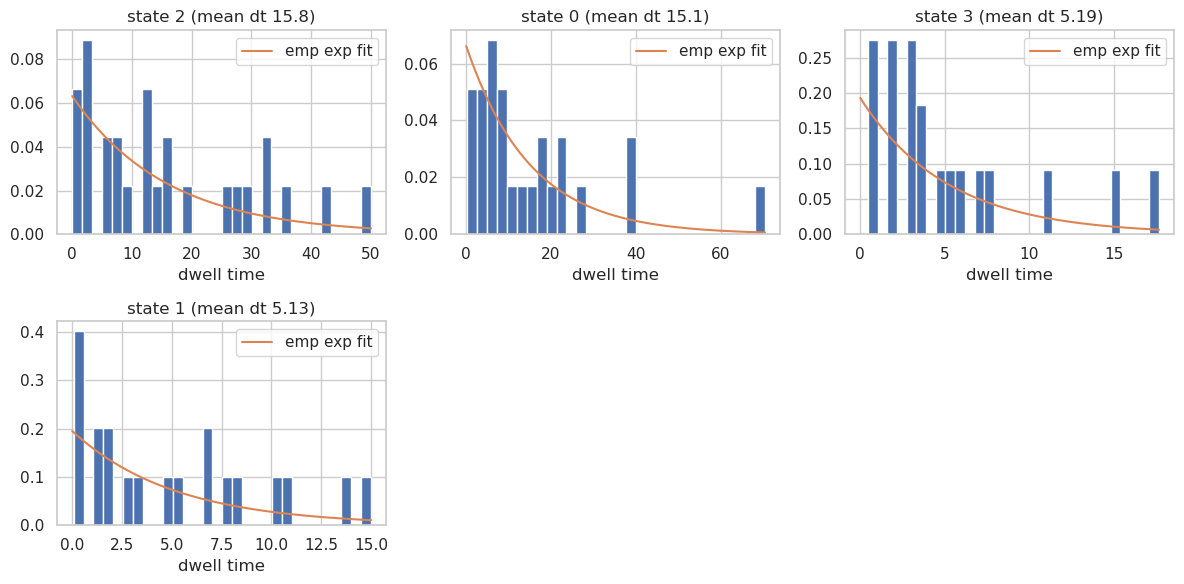

In [12]:
# Cell 11 — Gillespie simulation + single-run diagnostics and visualizations
# precompute neighbor arrays
neighbor_indices = [None] * N
neighbor_rates = [None] * N
neighbor_cumsums = [None] * N
neighbor_total_rates = np.zeros(N)
for i in range(N):
    nbrs = np.where(K_scaled[i] > 0)[0]
    if nbrs.size == 0:
        neighbor_indices[i] = np.array([], dtype=int)
        neighbor_rates[i] = np.array([], dtype=float)
        neighbor_cumsums[i] = np.array([], dtype=float)
        neighbor_total_rates[i] = 0.0
    else:
        rates = K_scaled[i, nbrs]
        cums = np.cumsum(rates)
        neighbor_indices[i] = nbrs
        neighbor_rates[i] = rates
        neighbor_cumsums[i] = cums
        neighbor_total_rates[i] = cums[-1]


def gillespie_ctmc_fast(neigh_idx, neigh_cums, neigh_tot, init_state, T_final, rng_local=None):
    if rng_local is None:
        rng_local = np.random.default_rng()
    state = int(init_state)
    t = 0.0
    times = [t]
    states = [state]
    local_log = math.log
    while t < T_final:
        R = neigh_tot[state]
        if R <= 0:
            logger.warning(f'Zero exit rate at state {state}; stopping simulation')
            break
        u = rng_local.random()
        dt = -local_log(u) / R
        v = rng_local.random() * R
        cums = neigh_cums[state]
        idx = np.searchsorted(cums, v, side='right')
        if idx >= len(neigh_idx[state]):
            idx = len(neigh_idx[state]) - 1
        next_state = int(neigh_idx[state][idx])
        t += dt
        times.append(t)
        states.append(next_state)
        state = next_state
    return np.array(times), np.array(states)

Tfinal = float(PARAMS['T_final'])
init = initial_cluster
times, states_seq = gillespie_ctmc_fast(neighbor_indices, neighbor_cumsums, neighbor_total_rates, init, Tfinal)
print(f'Generated {len(times)} events up to time {times[-1]:.3g}')

# timeline plot
plt.figure(figsize=(10,3))
plt.step(times, states_seq, where='post')
plt.xlabel('time'); plt.ylabel('state index')
plt.title('CTMC event-driven state timeline (step plot)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,3))
plt.scatter(times, states_seq, s=0.7, alpha=0.6)
plt.xlabel('time'); plt.ylabel('state index')
plt.title('CTMC events (scatter)')
plt.ylim(-1, N+1)
plt.tight_layout(); plt.show()

# dwell times and pi_hat
durations = np.diff(times)
states_during = states_seq[:-1]

total_time = durations.sum()
time_per_state = np.zeros(N)
visit_counts = np.zeros(N, dtype=int)
for s, dt in zip(states_during, durations):
    time_per_state[int(s)] += dt
    visit_counts[int(s)] += 1

pi_hat = time_per_state / (total_time + 1e-300)

# compare pi
plt.figure(figsize=(8,4))
order = np.argsort(pi)[::-1]
plt.bar(np.arange(min(20,N))-0.2, pi[order][:min(20,N)], width=0.4, label='input pi')
plt.bar(np.arange(min(20,N))+0.2, pi_hat[order][:min(20,N)], width=0.4, label='empirical pi_hat')
plt.xlabel('Cluster (top by input pi)'); plt.ylabel('probability')
plt.legend(); plt.title('Stationary distribution: input vs simulation (top)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5,5))
plt.scatter(pi, pi_hat, s=20, alpha=0.7)
plt.plot([0, pi.max()], [0, pi.max()], '--k')
plt.xlabel('input pi'); plt.ylabel('empirical pi_hat'); plt.title('pi vs pi_hat (all clusters)')
plt.tight_layout(); plt.show()

# mean dwell comparison
R_scaled = -np.diag(K_scaled)
mean_dwell_empirical = np.zeros(N)
for i in range(N):
    if visit_counts[i] > 0:
        mean_dwell_empirical[i] = time_per_state[i] / visit_counts[i]
    else:
        mean_dwell_empirical[i] = np.nan
mean_dwell_theory = 1.0 / (R_scaled + 1e-300)

topk = min(20, N)
top_states = order[:topk]
plt.figure(figsize=(6,5))
plt.scatter(mean_dwell_theory[top_states], mean_dwell_empirical[top_states])
maxv = np.nanmax(np.concatenate([mean_dwell_theory[top_states], mean_dwell_empirical[top_states]]))
plt.plot([0, maxv], [0, maxv], '--k')
plt.xlabel('theoretical mean dwell (=1/R)'); plt.ylabel('empirical mean dwell')
plt.title('Mean dwell time: theory vs simulation (top states)')
plt.tight_layout(); plt.show()

# dwell histograms for example states
num_examples = min(6, N)
example_states = np.argsort(pi)[-num_examples:][::-1]
plt.figure(figsize=(12,6))
for idx, s in enumerate(example_states):
    plt.subplot(2,3,idx+1)
    mask = (states_during == s)
    dts = durations[mask]
    if dts.size == 0:
        plt.title(f'state {s}: no visits')
        continue
    plt.hist(dts, bins=30, density=True)
    mean_dt = dts.mean()
    xs = np.linspace(0, dts.max(), 200)
    plt.plot(xs, (1/mean_dt)*np.exp(-xs/mean_dt), label='emp exp fit')
    plt.title(f'state {s} (mean dt {mean_dt:.3g})')
    plt.xlabel('dwell time'); plt.legend()
plt.tight_layout(); plt.show()

Stationary distribution: KL(pi||pi_hat) = 0.0566, L1 error = 0.314


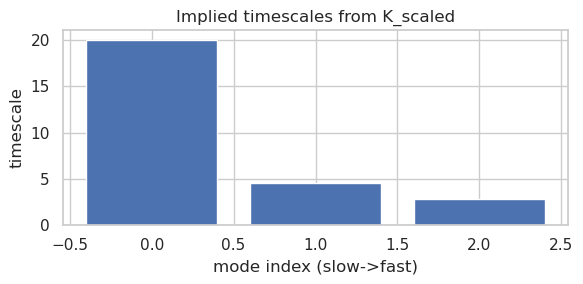

MFPT A->B comparison:
  Model (analytic from K) : 100.82
  MD empirical             : 259.35
  Simulation empirical     : 71.4


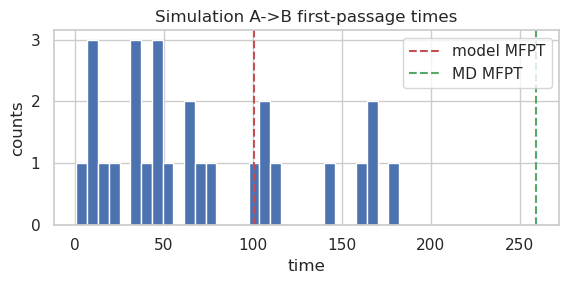

INFO:ctmc_nb:Saved ctmc_validation.npz with validation results


Total simulated time = 1.01e+03; visits per state (example top 10):
  state 2: pi=0.552, pi_hat=0.425, visits=27
  state 0: pi=0.276, pi_hat=0.376, visits=25
  state 3: pi=0.127, pi_hat=0.0979, visits=19
  state 1: pi=0.0445, pi_hat=0.102, visits=20
Number of zero-exit-rate states: 0


In [13]:
# Cell 12 — Validation metrics: KL, L1, timescales, MFPT comp
# 1) Stationary distribution error
eps = 1e-12
kl_div = np.sum(pi * np.log((pi + eps) / (pi_hat + eps)))
l1_err = np.sum(np.abs(pi - pi_hat))
print(f"Stationary distribution: KL(pi||pi_hat) = {kl_div:.3g}, L1 error = {l1_err:.3g}")

# 2) implied timescales
eigvals = np.linalg.eigvals(K_scaled)
real_parts = np.real(eigvals)
mask = real_parts < -1e-12
timescales = -1.0 / real_parts[mask]
timescales_sorted = np.sort(timescales)[::-1]

plt.figure(figsize=(6,3))
m = min(10, timescales_sorted.size)
plt.bar(range(m), timescales_sorted[:m])
plt.xlabel('mode index (slow->fast)'); plt.ylabel('timescale')
plt.title('Implied timescales from K_scaled')
plt.tight_layout(); plt.show()

# 3) MFPT: model vs simulation vs MD (if available)
mfpt_model = float(mfpt_model_A_to_B_scaled)

def compute_empirical_mfpt_from_events(times, states, A_idx, B_idx):
    n = len(states)
    hits = []
    i = 0
    while i < n:
        if states[i] == A_idx:
            j = i+1
            while j < n and states[j] != B_idx:
                j += 1
            if j < n and states[j] == B_idx:
                hits.append(times[j] - times[i])
            while i < n and states[i] == A_idx:
                i += 1
        else:
            i += 1
    if len(hits) == 0:
        return None, None
    return float(np.mean(hits)), np.array(hits)

mfpt_sim_mean, mfpt_sim_hits = compute_empirical_mfpt_from_events(times, states_seq, A_idx, B_idx)
print('MFPT A->B comparison:')
print(f'  Model (analytic from K) : {mfpt_model:.5g}')
if mfpt_md_mean is not None:
    print(f'  MD empirical             : {mfpt_md_mean:.5g}')
if mfpt_sim_mean is not None:
    print(f'  Simulation empirical     : {mfpt_sim_mean:.5g}')

if mfpt_sim_hits is not None and len(mfpt_sim_hits) > 0:
    plt.figure(figsize=(6,3))
    plt.hist(mfpt_sim_hits, bins=30)
    plt.axvline(mfpt_model, color='r', linestyle='--', label='model MFPT')
    if mfpt_md_mean is not None:
        plt.axvline(mfpt_md_mean, color='g', linestyle='--', label='MD MFPT')
    plt.title('Simulation A->B first-passage times')
    plt.xlabel('time'); plt.ylabel('counts'); plt.legend(); plt.tight_layout(); plt.show()
else:
    logger.info('No A->B first-passage events observed in simulation.')

# 4) visits and zero-rate states
zero_rate_states = np.sum(neighbor_total_rates <= 0)
print(f"Total simulated time = {total_time:.3g}; visits per state (example top 10):")
for s in order[:10]:
    print(f"  state {s}: pi={pi[s]:.3g}, pi_hat={pi_hat[s]:.3g}, visits={visit_counts[s]}")
print(f"Number of zero-exit-rate states: {zero_rate_states}")

# save validation outputs
np.savez(os.path.join(PARAMS['outputs_dir'], 'ctmc_validation.npz'), pi=pi, pi_hat=pi_hat, times=times, states=states_seq,
         mfpt_sim_hits=mfpt_sim_hits if mfpt_sim_hits is not None else np.array([]),
         timescales=timescales_sorted)
logger.info('Saved ctmc_validation.npz with validation results')

INFO:ctmc_nb:Producing MD-side diagnostic plots for visual comparison


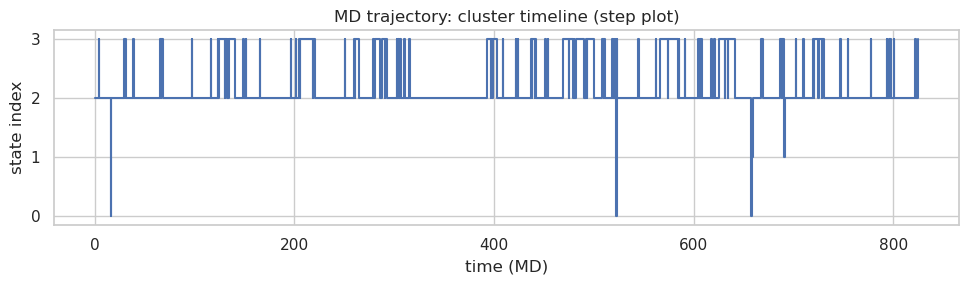

MD vs Model generator comparison (masked rows):
  Compared entries = 9
  Frobenius norm (off-diag masked) of K_md = 0.17702
  Frobenius norm of difference = 0.03963 (relative = 0.224)
  Pearson corr (off-diag masked) = 0.9663937126880011
  Mean abs relative error (where K_md>0) = 1.88


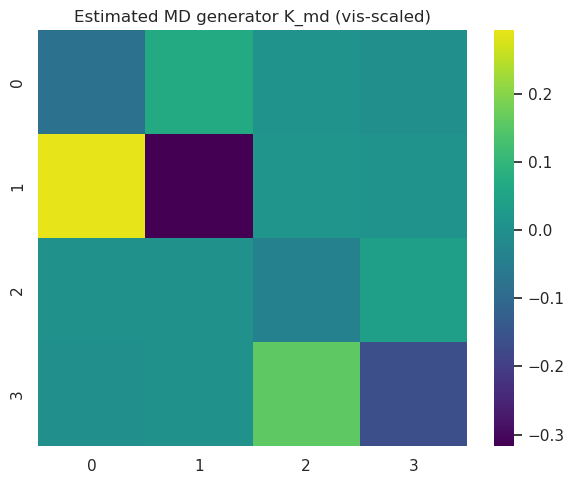

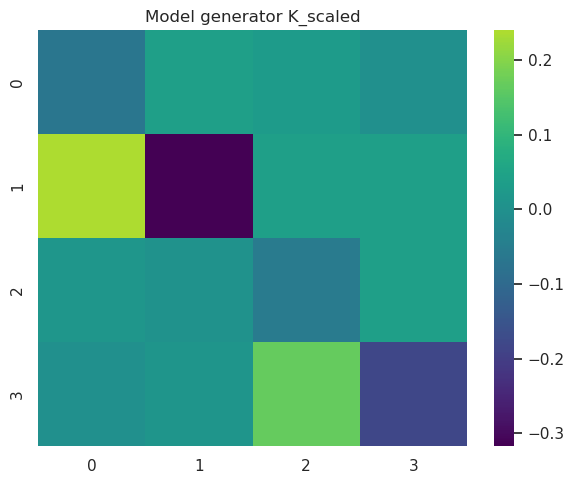

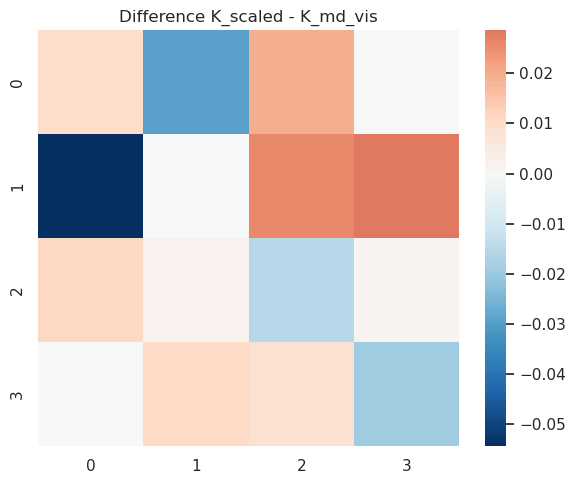

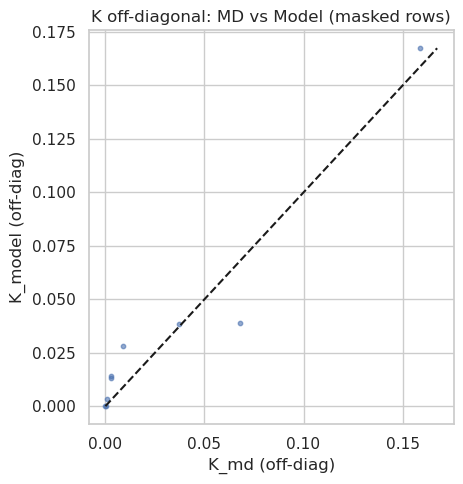

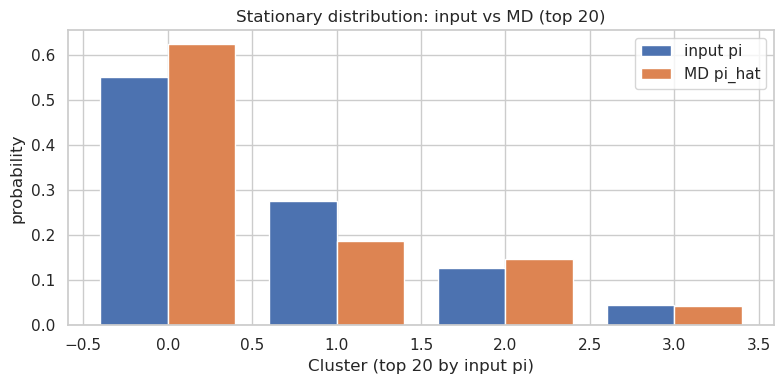

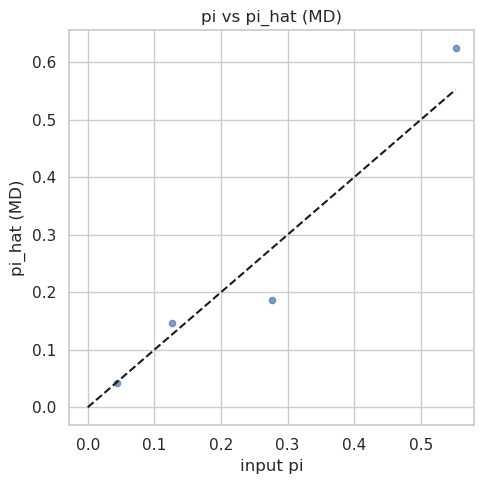

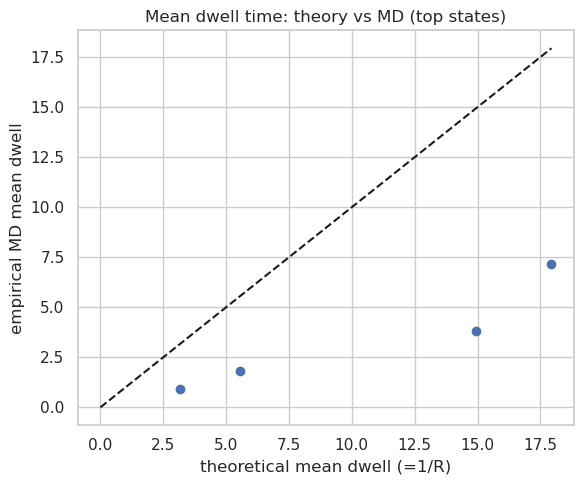

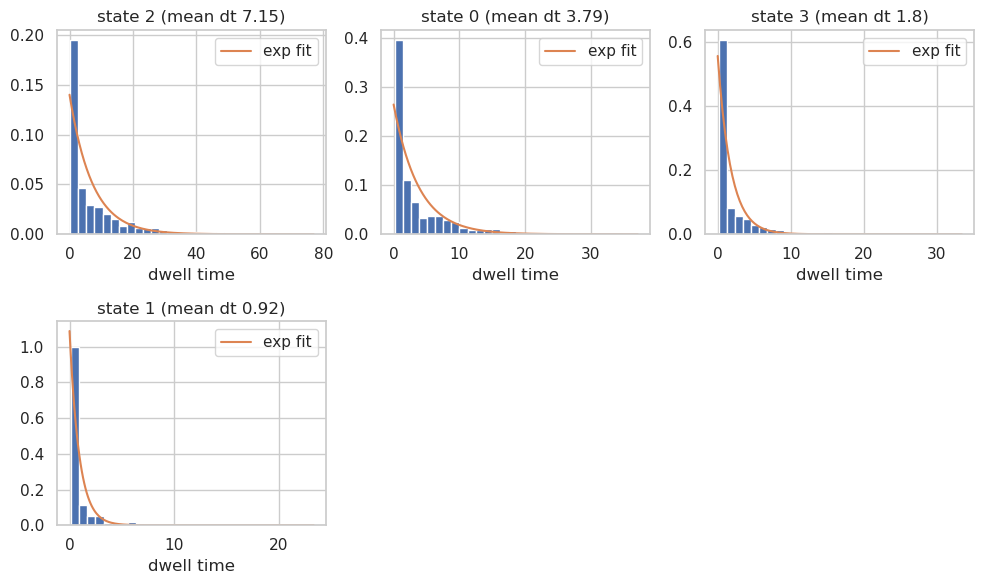

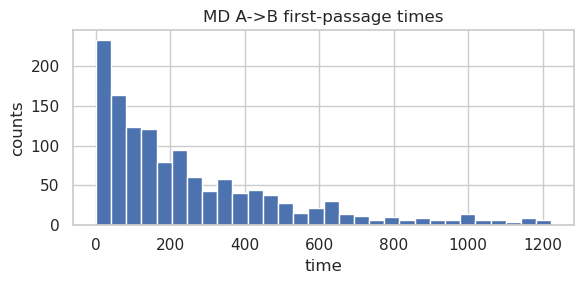

In [14]:
# Cell 13 — MD-side diagnostics: timelines, K_md comparison, plots
if feats_md is not None and labels_md is not None:
    logger.info('Producing MD-side diagnostic plots for visual comparison')
    n_md = len(labels_md)
    times_md = np.arange(n_md, dtype=float) * dt_md
    changes = np.where(labels_md[1:] != labels_md[:-1])[0] + 1
    times_md_events = np.concatenate(([0.0], times_md[changes]))
    states_md_seq = np.concatenate(([int(labels_md[0])], labels_md[changes].astype(int)))

    plt.figure(figsize=(10,3))
    cutoff = min(200, len(times_md_events))
    plt.step(times_md_events[:cutoff], states_md_seq[:cutoff], where='post')
    plt.xlabel('time (MD)'); plt.ylabel('state index')
    plt.title('MD trajectory: cluster timeline (step plot)')
    plt.tight_layout(); plt.show()

    # MD dwell aggregation
    change_frames = np.concatenate((changes, [n_md]))
    start_frames = np.concatenate(([0], changes))
    durations_frames = change_frames - start_frames
    durations_time = durations_frames * dt_md
    states_during_md = labels_md[start_frames]

    time_per_state_md = np.zeros(N)
    visit_counts_md = np.zeros(N, dtype=int)
    for s, dt_ in zip(states_during_md, durations_time):
        time_per_state_md[int(s)] += dt_
        visit_counts_md[int(s)] += 1
    total_time_md = durations_time.sum()
    pi_hat_md = time_per_state_md / (total_time_md + 1e-300)

    # Save K_md
    np.save(os.path.join(PARAMS['outputs_dir'], 'K_md.npy'), K_md)

    # comparison metrics
    K_md_local = K_md.copy()
    # optionally scale K_md visually to match K_scaled exit rates
    R_md = -np.diag(K_md_local)
    R_scaled = -np.diag(K_scaled)
    if R_md.max() > 0 and R_scaled.max() > 0:
        scale_vis = R_scaled.max() / R_md.max()
        K_md_vis = K_md_local * scale_vis
    else:
        K_md_vis = K_md_local

    # masked comparison
    K_model_all = K_scaled.copy()
    mask_off = ~np.eye(N, dtype=bool)
    row_mask = time_per_state_md >= max(1e-12, 0.05 * total_time_md)
    row_mask_mat = np.repeat(row_mask[:, None], N, axis=1)
    compare_mask = mask_off & row_mask_mat

    k_model_flat = K_model_all[compare_mask]
    k_md_flat = K_md_vis[compare_mask]
    finite_mask = np.isfinite(k_model_flat) & np.isfinite(k_md_flat)
    k_model_flat = k_model_flat[finite_mask]
    k_md_flat = k_md_flat[finite_mask]

    fro_diff = np.linalg.norm(k_model_flat - k_md_flat) if k_model_flat.size>0 else np.nan
    fro_md = np.linalg.norm(k_md_flat) if k_md_flat.size>0 else np.nan
    rel_fro = fro_diff / (fro_md + 1e-300) if not np.isnan(fro_md) else np.nan
    corr = np.corrcoef(k_model_flat, k_md_flat)[0,1] if k_model_flat.size>2 else np.nan
    nonzero_md = np.abs(k_md_flat) > 1e-12
    mare = np.mean(np.abs((k_model_flat[nonzero_md] - k_md_flat[nonzero_md]) / (k_md_flat[nonzero_md] + 1e-12))) if np.any(nonzero_md) else np.nan

    print('MD vs Model generator comparison (masked rows):')
    print(f'  Compared entries = {k_md_flat.size}')
    print(f'  Frobenius norm (off-diag masked) of K_md = {fro_md:.5g}')
    print(f'  Frobenius norm of difference = {fro_diff:.5g} (relative = {rel_fro:.3g})')
    print(f'  Pearson corr (off-diag masked) = {corr}')
    print(f'  Mean abs relative error (where K_md>0) = {mare:.3g}')

    # visualizations
    plt.figure(figsize=(6,5))
    sns.heatmap(K_md_vis, cmap='viridis', center=0)
    plt.title('Estimated MD generator K_md (vis-scaled)')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,5))
    sns.heatmap(K_scaled, cmap='viridis', center=0)
    plt.title('Model generator K_scaled')
    plt.tight_layout(); plt.show()

    diff_mat = K_scaled - K_md_vis
    plt.figure(figsize=(6,5))
    sns.heatmap(diff_mat, cmap='RdBu_r', center=0)
    plt.title('Difference K_scaled - K_md_vis')
    plt.tight_layout(); plt.show()

    # also show a bar plot of all entries in K_md vs K_model so that we can see if there are systematic deviations
    # plt.figure(figsize=(36,30))
    # k_md_flat_all = K_md_vis.flatten()
    # k_model_flat_all = K_scaled.flatten()
    # nonzero_mask = np.abs(k_md_flat_all) > 1e-12
    # k_md_flat_all = k_md_flat_all[nonzero_mask]
    # k_model_flat_all = k_model_flat_all[nonzero_mask]
    # plt.bar(np.arange(k_md_flat_all.size)-0.2, k_md_flat_all, width=0.4, label='K_md (off-diag)')
    # plt.bar(np.arange(k_md_flat_all.size)+0.2, k_model_flat_all, width=0.4, label='K_model (off-diag)')
    # plt.xlabel('entry index'); plt.ylabel('value')
    # plt.title('All off-diagonal entries: MD vs Model')
    # plt.legend(); plt.tight_layout(); plt.show()

    # scatter
    if k_md_flat.size > 0:
        plt.figure(figsize=(5,5))
        plt.scatter(k_md_flat, k_model_flat, s=10, alpha=0.6)
        mx = max(k_md_flat.max(), k_model_flat.max())
        mn = min(k_md_flat.min(), k_model_flat.min())
        plt.plot([mn, mx], [mn, mx], '--k')
        plt.xlabel('K_md (off-diag)'); plt.ylabel('K_model (off-diag)')
        plt.title('K off-diagonal: MD vs Model (masked rows)')
        plt.tight_layout(); plt.show()

    # pi comparison
    order = np.argsort(pi)[::-1]
    top_k = min(20, N)
    plt.figure(figsize=(8,4))
    plt.bar(np.arange(top_k)-0.2, pi[order][:top_k], width=0.4, label='input pi')
    plt.bar(np.arange(top_k)+0.2, pi_hat_md[order][:top_k], width=0.4, label='MD pi_hat')
    plt.xlabel('Cluster (top 20 by input pi)'); plt.ylabel('probability')
    plt.legend(); plt.title('Stationary distribution: input vs MD (top 20)')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(5,5))
    plt.scatter(pi, pi_hat_md, s=20, alpha=0.7)
    plt.plot([0, pi.max()], [0, pi.max()], '--k')
    plt.xlabel('input pi'); plt.ylabel('pi_hat (MD)'); plt.title('pi vs pi_hat (MD)')
    plt.tight_layout(); plt.show()

    # mean dwell comparison MD vs theory
    mean_dwell_empirical_md = np.zeros(N)
    for i in range(N):
        if visit_counts_md[i] > 0:
            mean_dwell_empirical_md[i] = time_per_state_md[i] / visit_counts_md[i]
        else:
            mean_dwell_empirical_md[i] = np.nan
    plt.figure(figsize=(6,5))
    topk = min(20, N)
    top_states = order[:topk]
    plt.scatter(mean_dwell_theory[top_states], mean_dwell_empirical_md[top_states])
    maxv = np.nanmax(np.concatenate([mean_dwell_theory[top_states], mean_dwell_empirical_md[top_states]]))
    plt.plot([0, maxv], [0, maxv], '--k')
    plt.xlabel('theoretical mean dwell (=1/R)'); plt.ylabel('empirical MD mean dwell')
    plt.title('Mean dwell time: theory vs MD (top states)')
    plt.tight_layout(); plt.show()

    # MD dwell histograms for example states
    plt.figure(figsize=(10,6))
    for idx, s in enumerate(example_states):
        plt.subplot(2,3,idx+1)
        mask = (states_during_md == s)
        dts = durations_time[mask]
        if dts.size == 0:
            plt.title(f'state {s}: no visits')
            continue
        plt.hist(dts, bins=30, density=True)
        mean_dt = dts.mean()
        xs = np.linspace(0, dts.max(), 200)
        plt.plot(xs, (1/mean_dt)*np.exp(-xs/mean_dt), label='exp fit')
        plt.title(f'state {s} (mean dt {mean_dt:.3g})')
        plt.xlabel('dwell time'); plt.legend()
    plt.tight_layout(); plt.show()

    # MD MFPT histogram if available
    if mfpt_md_mean is not None:
        plt.figure(figsize=(6,3))
        plt.hist(hit_times, bins=30)
        plt.title('MD A->B first-passage times')
        plt.xlabel('time'); plt.ylabel('counts'); plt.tight_layout(); plt.show()

else:
    logger.info('MD features or labels not available; skipping MD-side diagnostics')

INFO:ctmc_nb:Running 50 CTMC simulations for averaging...


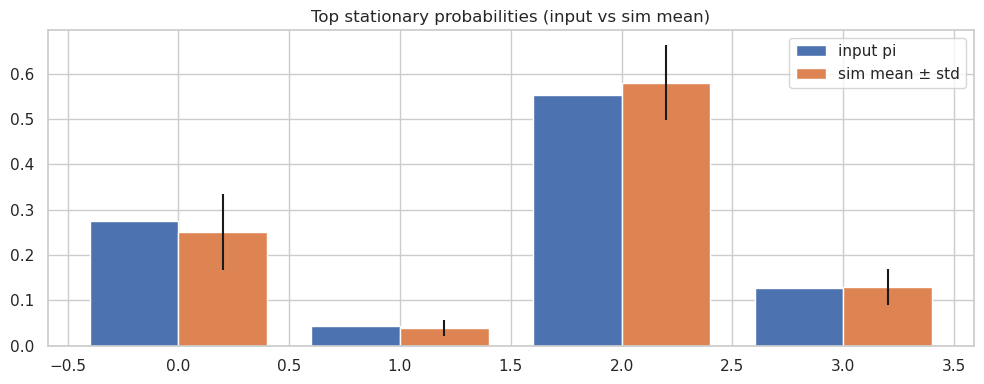

INFO:ctmc_nb:Loading MD trajectories from directory alanine-dipeptide-old
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_1.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_10.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_2.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_3.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_4.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_5.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_6.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_7.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_8.dcd
INFO:ctmc_nb:Processed MD file alanine-dipeptide-old/unwrapped_alanine_prod_9.dcd


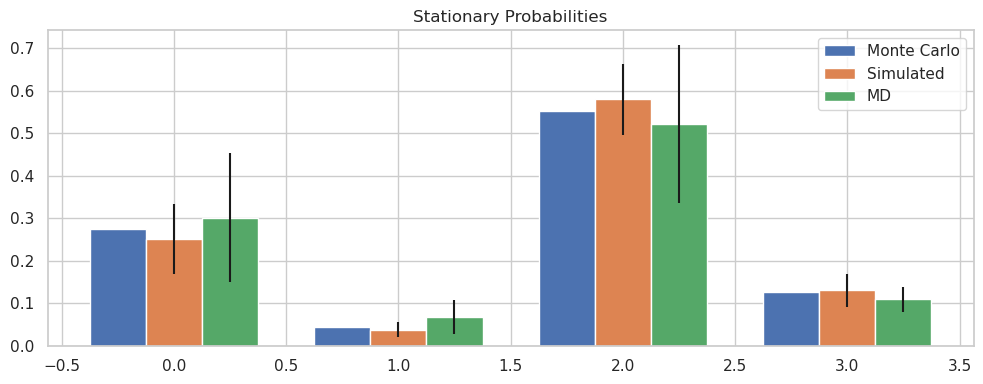

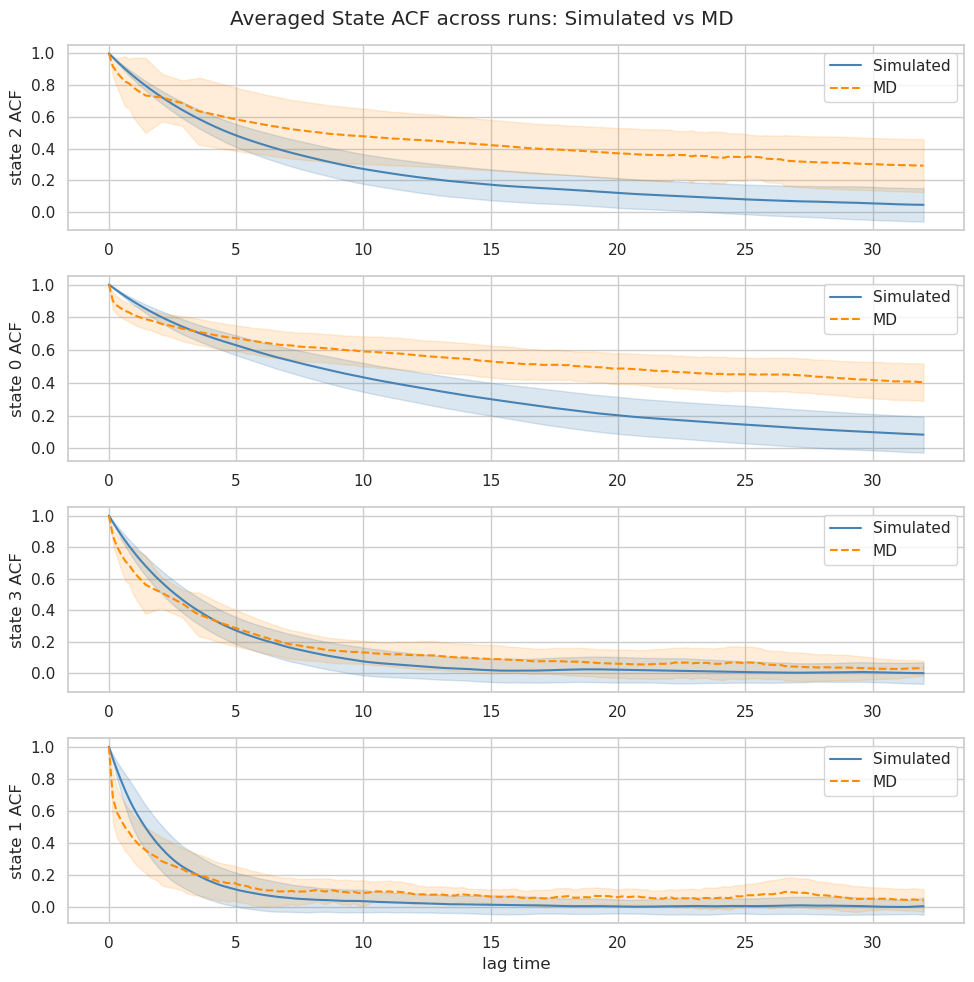

INFO:ctmc_nb:Built K_md_combined from all MD trajectories
INFO:ctmc_nb:Slow-mode scaling: c=1.979, tau_model=20.02, tau_md=10.12


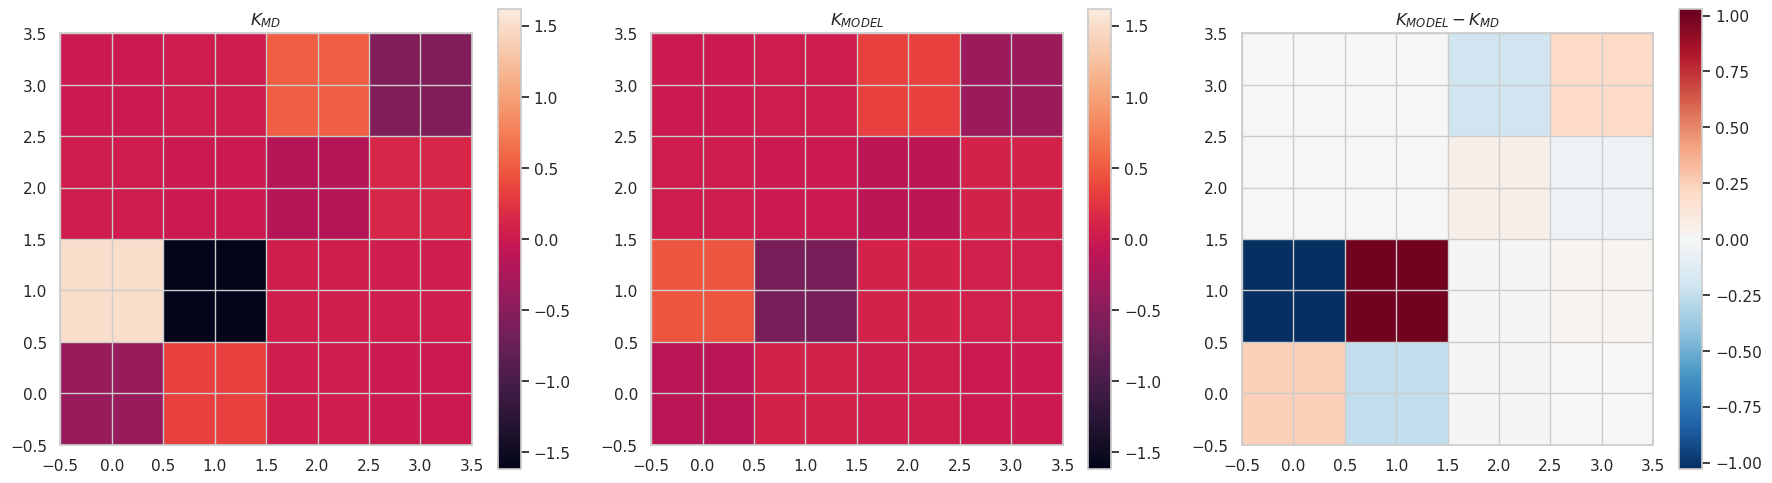

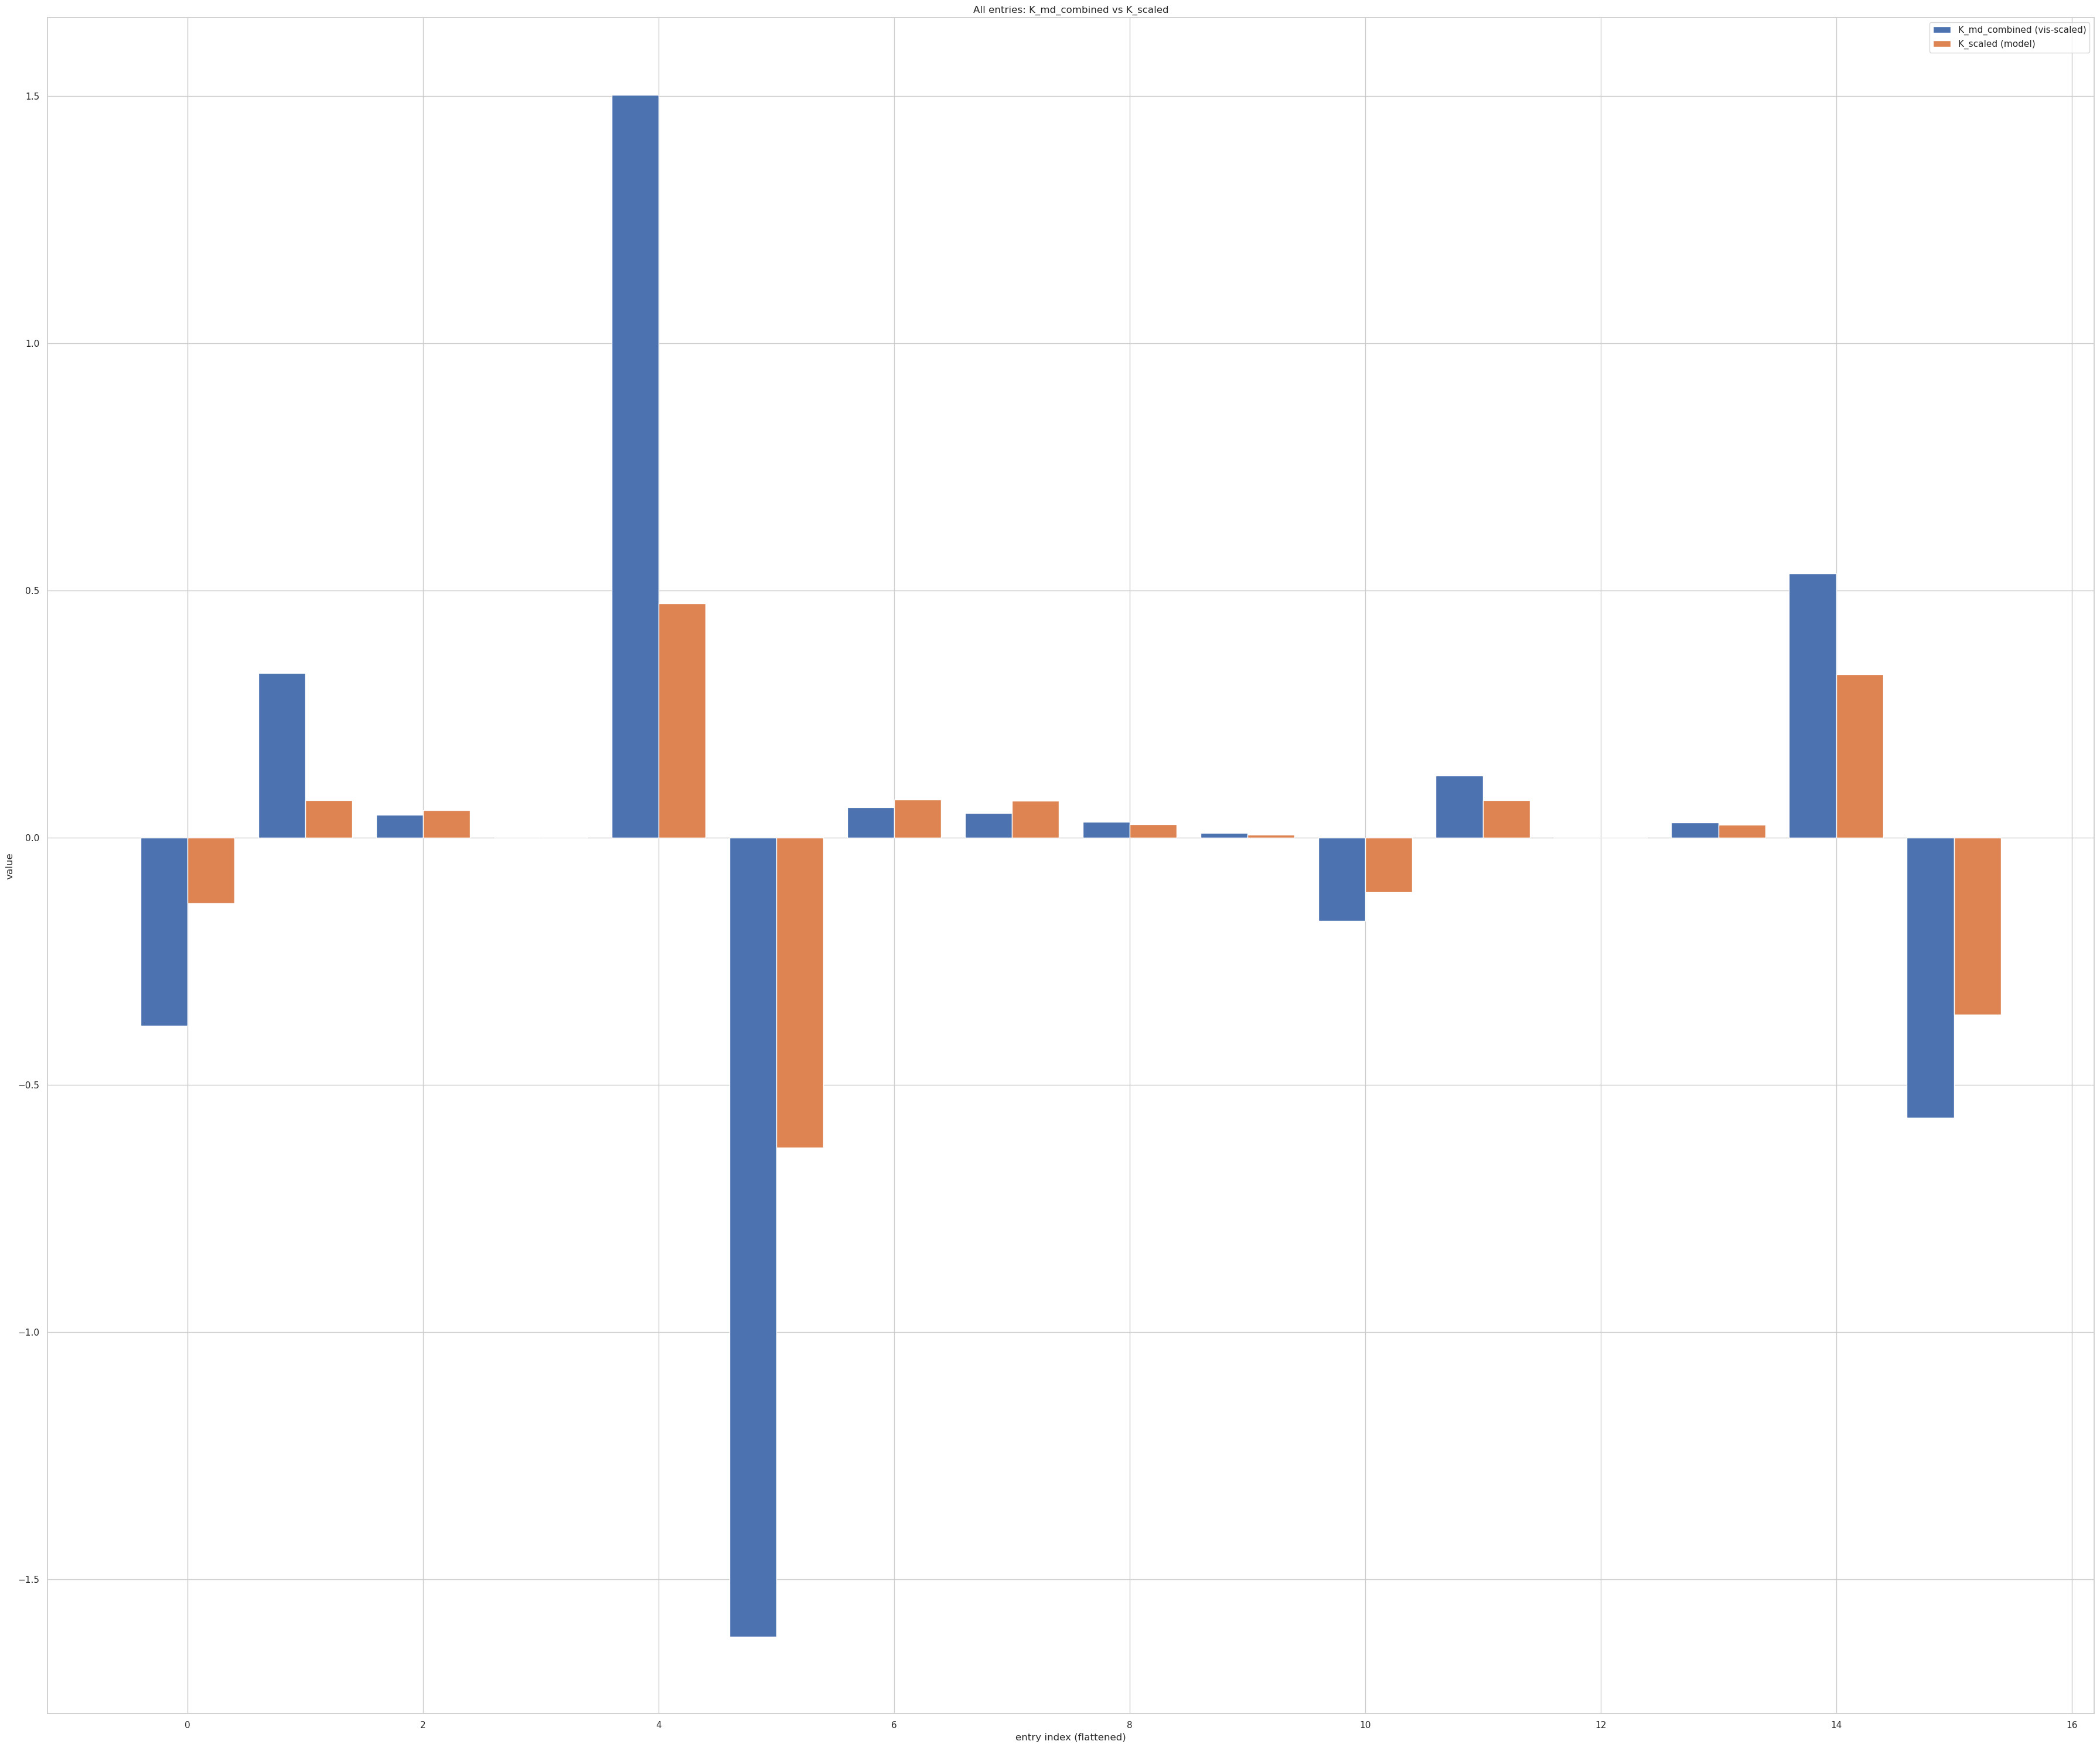


Combined MD vs Model generator comparison (masked rows):
  MD files used          = 11
  Compared entries       = 12
  Frobenius norm K_md    = 1.6375
  Frobenius norm diff    = 1.081  (relative = 0.66)
  Pearson corr           = 0.9423728775950835
  MARE (where K_md > 0) = 0.384


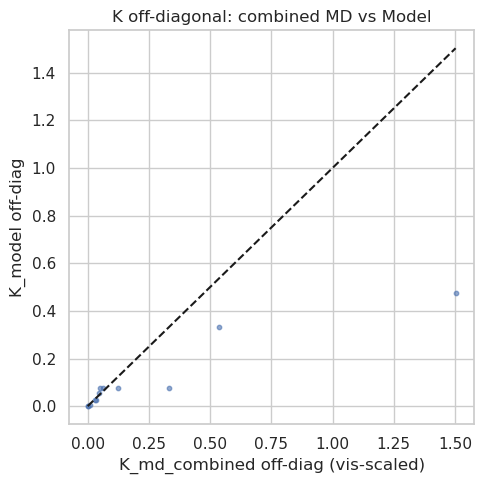

INFO:ctmc_nb:Saved K_md_combined.npy
INFO:ctmc_nb:Saved summary metrics


In [25]:
# Cell 14 — Multi-run simulations, averaging & ACF comparisons
# ---------------------------------------------------------------
# Changes vs previous version:
#   1. MD ACF (from all md_dir trajectories) is now overlaid on sim ACF plots
#   2. A combined K_md_combined is built from all MD files and compared to K_scaled

sim_runs = int(PARAMS['sim_runs'])
sim_pi_hats = []
sim_time_per_state = []
sim_total_times = []
sim_times_list = []
sim_states_list = []

logger.info(f'Running {sim_runs} CTMC simulations for averaging...')
for run_idx in range(sim_runs):
    if PARAMS['sim_random_start']:
        start = int(rng.integers(0, N))
    else:
        start = initial_cluster
    times_r, states_r = gillespie_ctmc_fast(
        neighbor_indices,
        neighbor_cumsums,
        neighbor_total_rates,
        start,
        Tfinal
    )
    sim_times_list.append(times_r)
    sim_states_list.append(states_r)

    durations_r = np.diff(times_r)
    states_during_r = states_r[:-1]
    time_per_state_run = np.zeros(N)
    for s, dt_ in zip(states_during_r, durations_r):
        time_per_state_run[int(s)] += dt_
    total_time_run = durations_r.sum()
    pi_hat_run = time_per_state_run / (total_time_run + 1e-300)

    sim_pi_hats.append(pi_hat_run)
    sim_time_per_state.append(time_per_state_run)
    sim_total_times.append(total_time_run)

sim_pi_hats_arr = np.vstack(sim_pi_hats)
sim_pi_mean = np.nanmean(sim_pi_hats_arr, axis=0)
sim_pi_std = np.nanstd(sim_pi_hats_arr, axis=0)

plt.figure(figsize=(10, 4))
# order = np.argsort(pi)[::-1]
# let order be as before, no sorting
order = np.arange(N)
x = np.arange(min(20, N))
plt.bar(x - 0.2, pi[order][:len(x)], width=0.4, label='input pi')
plt.bar(x + 0.2, sim_pi_mean[order][:len(x)], width=0.4,
        yerr=sim_pi_std[order][:len(x)], label='sim mean ± std')
plt.legend()
plt.title('Top stationary probabilities (input vs sim mean)')
plt.tight_layout()
plt.show()


# ============================================================
# Load all MD trajectories from directory (used for both
# population plot, ACF overlay, and combined K_md)
# ============================================================
md_pi_hat_mean = None

# Accumulators for combined K_md across all MD files
counts_md_combined   = np.zeros((N, N), dtype=float)
time_in_state_combined = np.zeros(N, dtype=float)

# Storage for per-file MD labels on a common time grid (for ACF)
md_acf_per_file = []   # each entry: array of shape (N, Klags+1)

# -------- ACF helpers (defined here so they're available below) --------
Klags   = 200
Tcomp   = min(np.min(sim_total_times), Tfinal)
if Tcomp <= 0:
    Tcomp = Tfinal
dt_grid   = dt_md if dt_md is not None else (Tcomp / 1000.0)
n_samples = int(min(5000, max(200, math.floor(Tcomp / dt_grid))))
t_grid_common = np.linspace(0.0, Tcomp, n_samples)


def compute_acf(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n < 2:
        return np.array([1.0])
    if max_lag is None:
        max_lag = n - 1
    max_lag = min(max_lag, n - 1)
    x_mean  = x.mean()
    x_cent  = x - x_mean
    acf_full = np.correlate(x_cent, x_cent, mode='full')
    acf  = acf_full[n - 1: n - 1 + (max_lag + 1)]
    denom = np.arange(n, n - len(acf), -1)
    acf  = acf / denom
    if acf[0] == 0:
        return acf
    acf = acf / acf[0]
    return acf


if PARAMS['md_dir'] is not None and os.path.isdir(PARAMS['md_dir']):
    logger.info(f"Loading MD trajectories from directory {PARAMS['md_dir']}")
    md_files = sorted([
        os.path.join(PARAMS['md_dir'], f)
        for f in os.listdir(PARAMS['md_dir'])
        if f.endswith(('.dcd', '.xtc', '.pdb'))
    ])
    md_pi_hat_list = []

    for mdf in md_files:
        try:
            tr     = load_trajectory(mdf, PARAMS['md_topology'])
            feats  = compute_features(tr, use_dihedrals=PARAMS['use_dihedrals'])
            labs   = np.argmin(cdist(feats, centroids), axis=1)
            dt_local = infer_dt(tr)
            if dt_local is None:
                dt_local = dt_md
            ############################### debug
            dt_local = dt_md
            ###############################
            n_frames = len(labs)

            # ---- population pi_hat for this file ----
            changes_f      = np.where(labs[1:] != labs[:-1])[0] + 1
            start_frames_f = np.concatenate(([0], changes_f))
            end_frames_f   = np.concatenate((changes_f, [n_frames]))
            dur_frames_f   = end_frames_f - start_frames_f
            dur_time_f     = dur_frames_f * dt_local
            states_block_f = labs[start_frames_f]

            time_per_state_f = np.zeros(N)
            for s, dt_ in zip(states_block_f, dur_time_f):
                time_per_state_f[int(s)] += dt_
            total_time_f    = dur_time_f.sum()
            pi_hat_f        = time_per_state_f / (total_time_f + 1e-300)
            md_pi_hat_list.append(pi_hat_f)

            # ---- accumulate counts & time for combined K_md ----
            prev_states_f = labs[changes_f - 1]
            next_states_f = labs[changes_f]
            for a, b in zip(prev_states_f, next_states_f):
                counts_md_combined[int(a), int(b)] += 1
            for s, dt_ in zip(states_block_f, dur_time_f):
                time_in_state_combined[int(s)] += dt_

            # ---- ACF for this MD file on the common grid ----
            times_md_f  = np.arange(n_frames, dtype=float) * dt_local
            grid_idxs_f = np.searchsorted(times_md_f, t_grid_common, side='right') - 1
            grid_idxs_f = np.clip(grid_idxs_f, 0, n_frames - 1)
            labs_grid_f = labs[grid_idxs_f]

            acf_this_file = np.full((N, Klags + 1), np.nan)
            for s in range(N):
                ind = (labs_grid_f == s).astype(float)
                if ind.sum() < 3:
                    continue
                acf = compute_acf(ind, max_lag=Klags)
                L   = len(acf)
                acf_this_file[s, :L] = acf
            md_acf_per_file.append(acf_this_file)

            logger.info(f"Processed MD file {mdf}")
        except Exception as e:
            logger.warning(f"Failed to process {mdf}: {e}")

    # ---- population bar chart (3-bar: input / sim / MD) ----
    if len(md_pi_hat_list) > 0:
        md_pi_hat_arr  = np.vstack(md_pi_hat_list)
        md_pi_hat_mean = np.nanmean(md_pi_hat_arr, axis=0)
        md_pi_hat_std  = np.nanstd(md_pi_hat_arr, axis=0)

        plt.figure(figsize=(10, 4))
        plt.bar(x - 0.25, pi[order][:len(x)],            width=0.25, label='Monte Carlo')
        plt.bar(x,         sim_pi_mean[order][:len(x)],  width=0.25,
                yerr=sim_pi_std[order][:len(x)],          label='Simulated')
        plt.bar(x + 0.25, md_pi_hat_mean[order][:len(x)], width=0.25,
                yerr=md_pi_hat_std[order][:len(x)],        label='MD')
        plt.legend()
        plt.title('Stationary Probabilities')
        plt.tight_layout()
        plt.show()


# ============================================================
# CHANGE 1 — Averaged ACF: simulation + MD overlay
# ============================================================
sim_acf_per_state = np.full((sim_runs, N, Klags + 1), np.nan)

for r in range(sim_runs):
    times_r  = sim_times_list[r]
    states_r = sim_states_list[r]
    sim_idxs = np.searchsorted(times_r, t_grid_common, side='right') - 1
    sim_idxs[sim_idxs < 0] = 0
    labels_sim_grid = states_r[sim_idxs]
    for s in range(N):
        ind = (labels_sim_grid == s).astype(float)
        if ind.sum() < 3:
            continue
        acf = compute_acf(ind, max_lag=Klags)
        L   = len(acf)
        sim_acf_per_state[r, s, :L] = acf

sim_acf_mean = np.nanmean(sim_acf_per_state, axis=0)
sim_acf_std  = np.nanstd(sim_acf_per_state,  axis=0)

# MD ACF mean/std across files
have_md_acf = len(md_acf_per_file) > 0
if have_md_acf:
    md_acf_arr  = np.stack(md_acf_per_file, axis=0)   # (n_files, N, Klags+1)
    md_acf_mean = np.nanmean(md_acf_arr, axis=0)
    md_acf_std  = np.nanstd(md_acf_arr,  axis=0)

states_to_plot = example_states
lags = np.arange(Klags + 1) * dt_grid

plt.figure(figsize=(10, 2.5 * len(states_to_plot)))
for idx, s in enumerate(states_to_plot):
    plt.subplot(len(states_to_plot), 1, idx + 1)

    # Simulation ACF
    plt.plot(lags, sim_acf_mean[s], color='steelblue', label='Simulated')
    plt.fill_between(lags,
                     sim_acf_mean[s] - sim_acf_std[s],
                     sim_acf_mean[s] + sim_acf_std[s],
                     alpha=0.2, color='steelblue')

    # MD ACF overlay (Change 1)
    if have_md_acf:
        plt.plot(lags, md_acf_mean[s], color='darkorange', linestyle='--', label='MD')
        plt.fill_between(lags,
                         md_acf_mean[s] - md_acf_std[s],
                         md_acf_mean[s] + md_acf_std[s],
                         alpha=0.15, color='darkorange')

    plt.ylabel(f'state {s} ACF')
    plt.legend()

plt.xlabel('lag time')
plt.suptitle('Averaged State ACF across runs: Simulated vs MD')
plt.tight_layout()
plt.show()


# ============================================================
# CHANGE 2 — Combined K_md from all MD files vs K_scaled
# ============================================================
K_md_combined = None

if time_in_state_combined.sum() > 0:
    K_md_combined = np.zeros((N, N), dtype=float)
    for i in range(N):
        if time_in_state_combined[i] > 0:
            K_md_combined[i, :] = counts_md_combined[i, :] / time_in_state_combined[i]
    for i in range(N):
        off_sum = np.sum(K_md_combined[i, :]) - K_md_combined[i, i]
        K_md_combined[i, i] = -off_sum

    logger.info('Built K_md_combined from all MD trajectories')

    # # --- vis-scale K_md_combined to match K_scaled exit rates ---
    # R_md_comb   = -np.diag(K_md_combined)
    # R_scaled_comb = -np.diag(K_scaled)
    # if R_md_comb.max() > 0 and R_scaled_comb.max() > 0:
    #     scale_vis_comb = R_scaled_comb.max() / R_md_comb.max()
    #     K_md_comb_vis  = K_md_combined * scale_vis_comb
    # else:
    #     K_md_comb_vis  = K_md_combined.copy()
    #     scale_vis_comb = 1.0
    # logger.info(f'Combined K_md vis-scale factor = {scale_vis_comb:.5g}')

    # --- vis-scale K_scaled to match K_md_combined exit rates (Change 2) ---
    if PARAMS['md_scale_by'] == 'max_exit':
        R_md_comb   = -np.diag(K_md_combined)
        R_scaled_comb = -np.diag(K_scaled)
        if R_md_comb.max() > 0 and R_scaled_comb.max() > 0:
            scale_vis_comb = R_md_comb.max() / R_scaled_comb.max()
            K_scaled_vis   = K_scaled * scale_vis_comb
        else:
            K_scaled_vis   = K_scaled.copy()
            scale_vis_comb = 1.0
        logger.info(f'Combined K_md vis-scale factor = {scale_vis_comb:.5g}')
        K_md_comb_vis = K_md_combined.copy()  # for clarity in plots, we keep K_md_combined as is and apply vis-scaling to K_scaled
    elif PARAMS['md_scale_by'] == 'slowest_exit':
        R_md_comb   = -np.diag(K_md_combined)
        R_scaled_comb = -np.diag(K_scaled)
        slowest_exit_md = np.min(R_md_comb[R_md_comb > 1e-12]) if np.any(R_md_comb > 1e-12) else 1.0
        slowest_exit_scaled = np.min(R_scaled_comb[R_scaled_comb > 1e-12]) if np.any(R_scaled_comb > 1e-12) else 1.0
        if slowest_exit_md > 0 and slowest_exit_scaled > 0:
            scale_vis_comb = slowest_exit_md / slowest_exit_scaled
            K_scaled_vis   = K_scaled * scale_vis_comb
        else:
            K_scaled_vis   = K_scaled.copy()
            scale_vis_comb = 1.0
        logger.info(f'Combined K_md vis-scale factor (slowest exit) = {scale_vis_comb:.5g}')
        K_md_comb_vis = K_md_combined.copy()
    elif PARAMS['md_scale_by'] == 'slowest_mode' and K_md_combined is not None:
        def get_slowest_eigval(Kmat, tol=1e-10):
            eigs = np.sort(np.real(np.linalg.eigvals(Kmat)))[::-1]
            nontrivial = eigs[eigs < -tol]
            return nontrivial[0] if len(nontrivial) > 0 else None
        
        lam_model = get_slowest_eigval(K_scaled)
        lam_md    = get_slowest_eigval(K_md_combined)
        
        if lam_model is not None and lam_md is not None:
            c_slow = lam_md / lam_model
            K_scaled_vis = K_scaled * c_slow
            logger.info(f'Slow-mode scaling: c={c_slow:.4g}, '
                        f'tau_model={-1/lam_model:.4g}, tau_md={-1/lam_md:.4g}')
        K_md_comb_vis = K_md_combined.copy()

    # --- heatmaps ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    totmax = max(np.nanmax(K_md_comb_vis), np.nanmax(K_scaled_vis))
    totmin = min(np.nanmin(K_md_comb_vis), np.nanmin(K_scaled_vis))

    totlims = max(abs(totmax), abs(totmin))

    im0 = axes[0].imshow(K_md_comb_vis, origin='lower', vmin=-totlims, vmax=totlims)
    axes[0].set_title('$K_{MD}$')
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(K_scaled_vis, origin='lower', vmin=-totlims, vmax=totlims)
    axes[1].set_title('$K_{MODEL}$')
    plt.colorbar(im1, ax=axes[1])

    diff_comb = K_scaled_vis - K_md_comb_vis
    vabs = np.nanmax(np.abs(diff_comb))
    im2 = axes[2].imshow(diff_comb, origin='lower', cmap='RdBu_r',
                         vmin=-vabs, vmax=vabs)
    axes[2].set_title('$K_{MODEL} - K_{MD}$')
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

    # bar chart for all entries in K_md_combined vs K_scaled (Change 2)
    k_model_flat_all = K_scaled_vis.flatten()
    k_md_flat_all    = K_md_comb_vis.flatten()
    finite_mask_all  = np.isfinite(k_model_flat_all) & np.isfinite(k_md_flat_all)
    k_model_flat_all = k_model_flat_all[finite_mask_all]
    k_md_flat_all    = k_md_flat_all[finite_mask_all]
    plt.figure(figsize=(36, 30))
    plt.bar(np.arange(len(k_md_flat_all)) - 0.2, k_md_flat_all, width=0.4, label='K_md_combined (vis-scaled)')
    plt.bar(np.arange(len(k_model_flat_all)) + 0.2, k_model_flat_all, width=0.4, label='K_scaled (model)')
    plt.xlabel('entry index (flattened)'); plt.ylabel('value'); plt.title('All entries: K_md_combined vs K_scaled')
    plt.legend(); plt.tight_layout(); plt.show()

    # --- masked quantitative comparison ---
    mask_off = ~np.eye(N, dtype=bool)
    total_time_combined = time_in_state_combined.sum()
    row_mask     = time_in_state_combined >= max(1e-12, 0.05 * total_time_combined)
    row_mask_mat = np.repeat(row_mask[:, None], N, axis=1)
    compare_mask = mask_off & row_mask_mat

    k_model_flat = K_scaled_vis[compare_mask]
    k_md_flat    = K_md_comb_vis[compare_mask]
    finite_mask  = np.isfinite(k_model_flat) & np.isfinite(k_md_flat)
    k_model_flat = k_model_flat[finite_mask]
    k_md_flat    = k_md_flat[finite_mask]

    fro_diff = np.linalg.norm(k_model_flat - k_md_flat) if k_model_flat.size > 0 else np.nan
    fro_md   = np.linalg.norm(k_md_flat)                if k_md_flat.size > 0    else np.nan
    rel_fro  = fro_diff / (fro_md + 1e-300)
    corr     = np.corrcoef(k_model_flat, k_md_flat)[0, 1] if k_model_flat.size > 2 else np.nan
    nonzero_md = np.abs(k_md_flat) > 1e-12
    mare = (np.mean(np.abs((k_model_flat[nonzero_md] - k_md_flat[nonzero_md])
                           / (k_md_flat[nonzero_md] + 1e-12)))
            if np.any(nonzero_md) else np.nan)

    print('\nCombined MD vs Model generator comparison (masked rows):')
    print(f'  MD files used          = {len(md_acf_per_file)}')
    print(f'  Compared entries       = {k_md_flat.size}')
    print(f'  Frobenius norm K_md    = {fro_md:.5g}')
    print(f'  Frobenius norm diff    = {fro_diff:.5g}  (relative = {rel_fro:.3g})')
    print(f'  Pearson corr           = {corr}')
    print(f'  MARE (where K_md > 0) = {mare:.3g}')

    # --- scatter plot ---
    if k_md_flat.size > 0:
        plt.figure(figsize=(5, 5))
        plt.scatter(k_md_flat, k_model_flat, s=10, alpha=0.6)
        mx = max(k_md_flat.max(), k_model_flat.max())
        mn = min(k_md_flat.min(), k_model_flat.min())
        plt.plot([mn, mx], [mn, mx], '--k')
        plt.xlabel('K_md_combined off-diag (vis-scaled)')
        plt.ylabel('K_model off-diag')
        plt.title('K off-diagonal: combined MD vs Model')
        plt.tight_layout()
        plt.show()

    # save combined K_md
    np.save(os.path.join(PARAMS['outputs_dir'], 'K_md_combined.npy'), K_md_combined)
    logger.info('Saved K_md_combined.npy')

else:
    logger.warning('No MD data accumulated for K_md_combined — '
                   'check that md_dir is set and contains valid trajectory files.')


# ============================================================
# Save summary metrics
# ============================================================
np.savez(os.path.join(PARAMS['outputs_dir'], 'summary_metrics.npz'),
         pi_input=pi,
         sim_pi_mean=sim_pi_mean,
         sim_pi_std=sim_pi_std,
         md_pi_mean=md_pi_hat_mean if md_pi_hat_mean is not None else np.array([]))
logger.info('Saved summary metrics')

In [16]:
# Compute implied timescales from K_scaled vs K_md_combined
eigvals_model = np.sort(np.real(np.linalg.eigvals(K_scaled_vis)))[::-1]
eigvals_md = np.sort(np.real(np.linalg.eigvals(K_md_comb_vis)))[::-1]

# The slowest few timescales should match
timescales_model = -1.0 / eigvals_model[eigvals_model < -1e-12]
timescales_md = -1.0 / eigvals_md[eigvals_md < -1e-12]

print('Implied timescales (model vs combined MD):')
for i in range(min(10, len(timescales_model), len(timescales_md))):
    print(f'  Mode {i}: model = {timescales_model[i]:.3g}, MD_combined = {timescales_md[i]:.3g}')

Implied timescales (model vs combined MD):
  Mode 0: model = 10.1, MD_combined = 10.1
  Mode 1: model = 2.32, MD_combined = 1.44
  Mode 2: model = 1.44, MD_combined = 0.516


In [17]:
# Cell 15 — Export PDB/CSV of simulated trajectories & save generators
# Export representative PDB frames for visualizing event-driven sim (one model per event)
if backend == 'mdtraj' and isinstance(mc_traj, md.Trajectory):
    mc_coords = mc_traj.xyz
    d_to_cent = cdist(feats_mc, centroids)
    rep_idx = np.argmin(d_to_cent, axis=0)
    centroid_coords = mc_coords[rep_idx]
    # write for sim_view run
    sim_view = int(PARAMS['sim_view_index'])
    sim_view = max(0, min(sim_view, len(sim_states_list)-1))
    states_for_write = sim_states_list[sim_view]
    n_models = min(len(states_for_write), PARAMS['max_models'])
    frames_to_write = np.empty((n_models, centroid_coords.shape[1], 3), dtype=float)
    for i in range(n_models):
        frames_to_write[i] = centroid_coords[int(states_for_write[i])]
    traj_out = md.Trajectory(frames_to_write, topology=mc_traj.top)
    out_pdb = os.path.join(PARAMS['outputs_dir'], f'ctmc_simulated_traj_run_{sim_view}.pdb')
    traj_out.save(out_pdb)
    logger.info(f'Wrote {out_pdb}')

# Save K and centroids
np.save(os.path.join(PARAMS['outputs_dir'], 'K_scaled.npy'), K_scaled)
np.save(os.path.join(PARAMS['outputs_dir'], 'centroids.npy'), centroids)
np.save(os.path.join(PARAMS['outputs_dir'], 'pi.npy'), pi)

# events CSV for first sim
out_csv = os.path.join(PARAMS['outputs_dir'], 'ctmc_events.csv')
import csv
with open(out_csv, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['time', 'state'])
    for t, s in zip(times, states_seq):
        w.writerow([t, int(s)])
logger.info(f'Wrote events to {out_csv}')

print('Done — Notebook execution finished. Outputs in', PARAMS['outputs_dir'])

INFO:ctmc_nb:Wrote alanine_dipeptide_ctmc_outputs/ctmc_simulated_traj_run_0.pdb
INFO:ctmc_nb:Wrote events to alanine_dipeptide_ctmc_outputs/ctmc_events.csv


Done — Notebook execution finished. Outputs in alanine_dipeptide_ctmc_outputs


Reference MFPT (full MD length) from K_scaled_vis: 51 ps

frac=0.020 | length=300.0 ps | n_trans=62 | MFPT=7.25 | err=85.8% | relFro=6.027
frac=0.024 | length=353.0 ps | n_trans=74 | MFPT=6.5 | err=87.2% | relFro=6.841
frac=0.028 | length=415.5 ps | n_trans=82 | MFPT=6.91 | err=86.4% | relFro=6.371
frac=0.033 | length=489.1 ps | n_trans=105 | MFPT=7.21 | err=85.8% | relFro=6.067
frac=0.038 | length=575.7 ps | n_trans=134 | MFPT=6.93 | err=86.4% | relFro=6.357
frac=0.045 | length=677.8 ps | n_trans=162 | MFPT=7.38 | err=85.5% | relFro=5.905
frac=0.053 | length=797.6 ps | n_trans=193 | MFPT=7.07 | err=86.1% | relFro=6.210
frac=0.063 | length=938.9 ps | n_trans=233 | MFPT=6.59 | err=87.1% | relFro=6.728
frac=0.074 | length=1105.1 ps | n_trans=283 | MFPT=7.14 | err=86.0% | relFro=6.138
frac=0.087 | length=1300.8 ps | n_trans=329 | MFPT=7.35 | err=85.6% | relFro=5.930
frac=0.102 | length=1531.0 ps | n_trans=406 | MFPT=50.8 | err=0.4% | relFro=0.004
frac=0.120 | length=1802.2 ps | n_trans=48

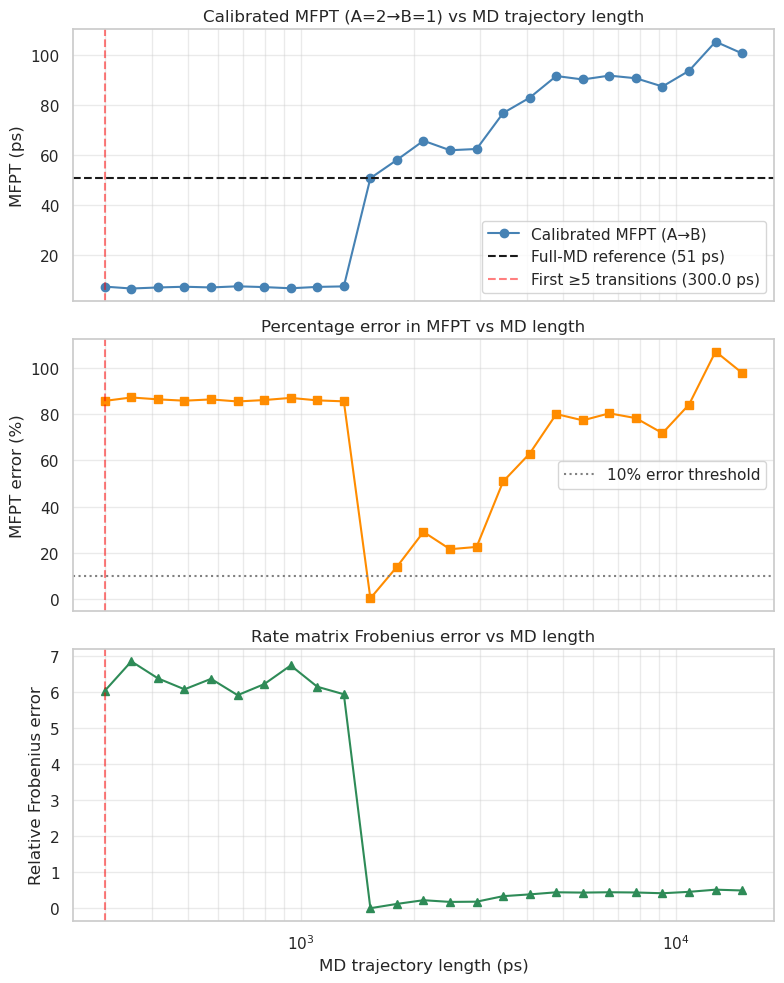


── MD Length Sensitivity Summary ──
 Length (ps)  N_trans       MFPT    Err %   RelFro
       300.0       62       7.25     85.8    6.027
       353.0       74        6.5     87.2    6.841
       415.5       82       6.91     86.4    6.371
       489.1      105       7.21     85.8    6.067
       575.7      134       6.93     86.4    6.357
       677.8      162       7.38     85.5    5.905
       797.6      193       7.07     86.1    6.210
       938.9      233       6.59     87.1    6.728
      1105.1      283       7.14     86.0    6.138
      1300.8      329       7.35     85.6    5.930
      1531.0      406       50.8      0.4    0.004
      1802.2      485       58.1     14.0    0.123
      2121.3      539       65.8     29.1    0.225
      2496.8      639         62     21.6    0.178
      2938.9      739       62.5     22.6    0.184
      3459.2      884       76.9     50.9    0.337
      4071.5     1110       83.1     63.0    0.387
      4792.5     1366       91.8     80.1    

In [18]:
# Cell 16 — MD trajectory length sensitivity analysis
# Tests how calibration quality changes as a function of MD trajectory length used
# Run AFTER Cell 10 (K_md and K_scaled are available)
# Requires: labels_md, dt_md, N, K, K_scaled, A_idx, B_idx, centroids, pi

import numpy as np
import matplotlib.pyplot as plt

def compute_scaled_K_from_labels(labels_md_sub, dt_md, N, K):
    """Estimate K_md from a subset of MD labels and return scaled K."""
    labels_md_sub = np.asarray(labels_md_sub, dtype=int)
    n = len(labels_md_sub)
    if n < 2:
        return None, None

    changes = np.where(labels_md_sub[1:] != labels_md_sub[:-1])[0] + 1
    if len(changes) == 0:
        return None, None

    prev_states = labels_md_sub[changes - 1]
    next_states = labels_md_sub[changes]
    counts_sub = np.zeros((N, N), dtype=float)
    for a, b in zip(prev_states, next_states):
        counts_sub[int(a), int(b)] += 1

    change_frames = np.concatenate((changes, [n]))
    start_frames = np.concatenate(([0], changes))
    dur_frames = change_frames - start_frames
    states_block = labels_md_sub[start_frames]

    time_in_state = np.zeros(N, dtype=float)
    for s, df in zip(states_block, dur_frames):
        time_in_state[int(s)] += df * dt_md

    K_md_sub = np.zeros((N, N), dtype=float)
    for i in range(N):
        if time_in_state[i] > 0:
            K_md_sub[i, :] = counts_sub[i, :] / time_in_state[i]
    for i in range(N):
        off_sum = np.sum(K_md_sub[i, :]) - K_md_sub[i, i]
        K_md_sub[i, i] = -off_sum

    # scale K using method consistent with main analysis
    if PARAMS['md_scale_by'] == 'max_exit':
        # print('Using max-exit scaling for this subset of MD data')
        R_md_sub = -np.diag(K_md_sub)
        R_model = -np.diag(K)
        if np.max(R_md_sub) <= 0 or np.max(R_model) <= 0:
            return None, None

        scale_c = np.max(R_md_sub) / np.max(R_model)
        K_scaled_sub = K * scale_c
    elif PARAMS['md_scale_by'] == 'slowest_exit':
        # print('Using slowest-exit scaling for this subset of MD data')
        R_md_sub = -np.diag(K_md_sub)
        R_model = -np.diag(K)
        slowest_exit_md = np.min(R_md_sub[R_md_sub > 1e-12]) if np.any(R_md_sub > 1e-12) else 1.0
        slowest_exit_model = np.min(R_model[R_model > 1e-12]) if np.any(R_model > 1e-12) else 1.0
        if slowest_exit_md <= 0 or slowest_exit_model <= 0:
            return None, None

        scale_c = slowest_exit_md / slowest_exit_model
        K_scaled_sub = K * scale_c
    elif PARAMS['md_scale_by'] == 'slowest_mode':
        # print('Using slowest-mode scaling for this subset of MD data')
        def get_slowest_eigval(Kmat, tol=1e-10):
            eigs = np.sort(np.real(np.linalg.eigvals(Kmat)))[::-1]
            nontrivial = eigs[eigs < -tol]
            return nontrivial[0] if len(nontrivial) > 0 else None
        
        lam_model = get_slowest_eigval(K)
        lam_md_sub = get_slowest_eigval(K_md_sub)
        
        if lam_model is None or lam_md_sub is None:
            return None, None
        
        scale_c = lam_md_sub / lam_model
        K_scaled_sub = K * scale_c
    else:        raise ValueError(f"Invalid md_scale_by option: {PARAMS['md_scale_by']}")

    n_transitions = int(len(changes))
    return K_scaled_sub, n_transitions


def mfpt_from_K(Kmat, A, B):
    """Analytic MFPT from state A to state B."""
    N = Kmat.shape[0]
    transient = [i for i in range(N) if i != B]
    K_RR = Kmat[np.ix_(transient, transient)]
    try:
        t_sol = np.linalg.solve(-K_RR, np.ones(len(transient)))
    except np.linalg.LinAlgError:
        return np.nan
    t_all = np.zeros(N)
    for ii, si in enumerate(transient):
        t_all[si] = t_sol[ii]
    return float(t_all[A])


# ── Parameters ──────────────────────────────────────────────────────────────
# Fractions of MD trajectory to use (log-spaced for better resolution at short lengths)
fracs = np.logspace(np.log10(0.02), np.log10(1.0), 25)

# Reference values from full trajectory
mfpt_ref = mfpt_from_K(K_scaled_vis, A_idx, B_idx)
print(f"Reference MFPT (full MD length) from K_scaled_vis: {mfpt_ref:.3g} ps\n")

R_model_full = -np.diag(K)
R_md_full = -np.diag(K_md_comb_vis)

# Off-diagonal mask for Frobenius comparison (rows with enough data at full length)
mask_off = ~np.eye(N, dtype=bool)

# ── Main sweep ───────────────────────────────────────────────────────────────
n_total_frames = len(labels_md)
results = []

for frac in fracs:
    n_frames_sub = max(10, int(frac * n_total_frames))
    labels_sub = labels_md[:n_frames_sub]
    traj_length_ps = n_frames_sub * dt_md

    K_scaled_sub, n_trans = compute_scaled_K_from_labels(labels_sub, dt_md, N, K)

    if K_scaled_sub is None:
        results.append({
            'frac': frac,
            'traj_length_ps': traj_length_ps,
            'n_transitions': 0,
            'mfpt_AB': np.nan,
            'mfpt_err_pct': np.nan,
            'rel_fro': np.nan,
        })
        continue

    mfpt_sub = mfpt_from_K(K_scaled_sub, A_idx, B_idx)
    mfpt_err_pct = abs(mfpt_sub - mfpt_ref) / (abs(mfpt_ref) + 1e-12) * 100.0

    # Frobenius error vs full K_scaled
    k_sub_flat = K_scaled_sub[mask_off]
    k_full_flat = K_scaled_vis[mask_off]
    fro_diff = np.linalg.norm(k_sub_flat - k_full_flat)
    fro_full = np.linalg.norm(k_full_flat)
    rel_fro = fro_diff / (fro_full + 1e-12)

    results.append({
        'frac': frac,
        'traj_length_ps': traj_length_ps,
        'n_transitions': n_trans,
        'mfpt_AB': mfpt_sub,
        'mfpt_err_pct': mfpt_err_pct,
        'rel_fro': rel_fro,
    })

    print(f"frac={frac:.3f} | length={traj_length_ps:.1f} ps | "
          f"n_trans={n_trans} | MFPT={mfpt_sub:.3g} | "
          f"err={mfpt_err_pct:.1f}% | relFro={rel_fro:.3f}")

lengths    = np.array([r['traj_length_ps'] for r in results])
mfpts      = np.array([r['mfpt_AB']        for r in results])
errs       = np.array([r['mfpt_err_pct']   for r in results])
rel_fros   = np.array([r['rel_fro']        for r in results])
n_trans_arr = np.array([r['n_transitions'] for r in results])

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Panel 1: MFPT vs trajectory length
axes[0].semilogx(lengths, mfpts, 'o-', color='steelblue', label='Calibrated MFPT (A→B)')
axes[0].axhline(mfpt_ref, color='k', linestyle='--', label=f'Full-MD reference ({mfpt_ref:.3g} ps)')
axes[0].set_ylabel('MFPT (ps)')
axes[0].set_title(f'Calibrated MFPT (A={A_idx}→B={B_idx}) vs MD trajectory length')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.4)

# Panel 2: % error in MFPT
axes[1].semilogx(lengths, errs, 's-', color='darkorange')
axes[1].axhline(10, color='gray', linestyle=':', label='10% error threshold')
axes[1].set_ylabel('MFPT error (%)')
axes[1].set_title('Percentage error in MFPT vs MD length')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.4)

# Panel 3: Relative Frobenius error
axes[2].semilogx(lengths, rel_fros, '^-', color='seagreen')
axes[2].set_ylabel('Relative Frobenius error')
axes[2].set_xlabel('MD trajectory length (ps)')
axes[2].set_title('Rate matrix Frobenius error vs MD length')
axes[2].grid(True, which='both', alpha=0.4)

# Mark the point where n_transitions first exceeds a threshold
thresh = 5
for i, r in enumerate(results):
    if r['n_transitions'] >= thresh:
        for ax in axes:
            ax.axvline(lengths[i], color='red', linestyle='--', alpha=0.5,
                       label=f'First ≥{thresh} transitions ({lengths[i]:.1f} ps)')
        axes[0].legend()
        break

plt.tight_layout()
plt.savefig(os.path.join(PARAMS['outputs_dir'], 'md_length_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── MD Length Sensitivity Summary ──")
print(f"{'Length (ps)':>12} {'N_trans':>8} {'MFPT':>10} {'Err %':>8} {'RelFro':>8}")
for r in results:
    print(f"{r['traj_length_ps']:>12.1f} {r['n_transitions']:>8} "
          f"{r['mfpt_AB']:>10.3g} {r['mfpt_err_pct']:>8.1f} {r['rel_fro']:>8.3f}")

# Find convergence point (first time error stays below 15% for 3 consecutive points)
converged_length = None
for i in range(len(results) - 2):
    if all(results[j]['mfpt_err_pct'] < 15 for j in [i, i+1, i+2]):
        converged_length = results[i]['traj_length_ps']
        converged_n_trans = results[i]['n_transitions']
        break

if converged_length is not None:
    print(f"\nCalibration converges (err < 15% for 3 consecutive points) at:")
    print(f"  MD length = {converged_length:.1f} ps")
    print(f"  N transitions at that point = {converged_n_trans}")
    full_length = lengths[-1]
    print(f"  Full MD length = {full_length:.1f} ps")
    print(f"  Compression factor = {full_length/converged_length:.1f}x")
else:
    print("\nCalibration did not converge within the tested range.")